### IMPORT REQUIRED LIBRARIES

In [1]:
print("=" * 60)
print("IMPORTING REQUIRED LIBRARIES")
print("=" * 60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")


IMPORTING REQUIRED LIBRARIES
✅ Libraries imported successfully!


### LOAD AND EXPLORE THE DATASET

In [3]:
print("\n" + "=" * 60)
print("STEP 2: LOADING AND EXPLORING THE DATASET")
print("=" * 60)

# Load the dataset
file_path = r"C:\Users\Shyam\Downloads\energy consumption dataset\SM Cleaned Data BR2019.csv"

try:
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ File not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"❌ Error loading file: {e}")
    exit()

# Display basic information
print(f"\nDataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\n📋 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\n📊 Data Types:")
print(df.dtypes)

print("\n🔍 First 5 rows:")
print(df.head())

print("\n📈 Basic Statistics:")
print(df.describe())


STEP 2: LOADING AND EXPLORING THE DATASET
✅ Dataset loaded successfully!

Dataset Shape: (2919315, 6)
Number of rows: 2919315
Number of columns: 6

📋 Column Names:
1. x_Timestamp
2. t_kWh
3. z_Avg Voltage (Volt)
4. z_Avg Current (Amp)
5. y_Freq (Hz)
6. meter

📊 Data Types:
x_Timestamp              object
t_kWh                   float64
z_Avg Voltage (Volt)    float64
z_Avg Current (Amp)     float64
y_Freq (Hz)             float64
meter                    object
dtype: object

🔍 First 5 rows:
           x_Timestamp  t_kWh  z_Avg Voltage (Volt)  z_Avg Current (Amp)  \
0  2019-07-10 00:00:00  0.021                243.10                 1.79   
1  2019-07-10 00:03:00  0.021                242.91                 1.80   
2  2019-07-10 00:06:00  0.021                242.46                 1.83   
3  2019-07-10 00:09:00  0.020                241.27                 1.79   
4  2019-07-10 00:12:00  0.020                240.77                 1.79   

   y_Freq (Hz) meter  
0        50.02  BR02  

### CHECK FOR MISSING VALUES


CHECKING FOR MISSING VALUES
Missing Values Summary:
                      Missing_Values  Percentage
x_Timestamp                        0         0.0
t_kWh                              0         0.0
z_Avg Voltage (Volt)               0         0.0
z_Avg Current (Amp)                0         0.0
y_Freq (Hz)                        0         0.0
meter                              0         0.0


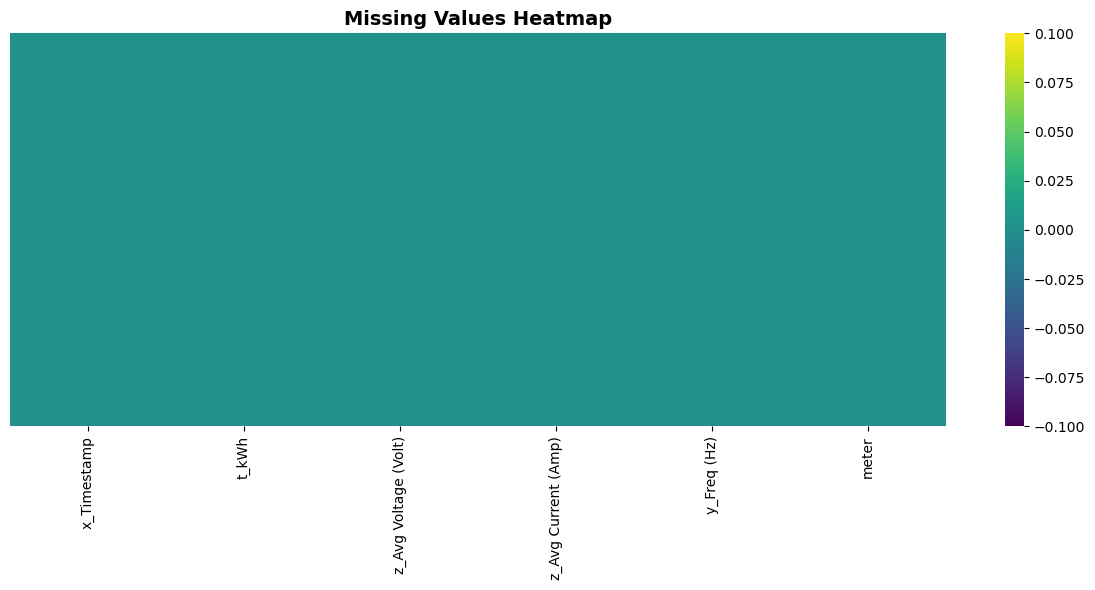

In [5]:
print("\n" + "=" * 60)
print("CHECKING FOR MISSING VALUES")
print("=" * 60)

# Check missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing_Values': missing_values,
    'Percentage': missing_percentage
}).sort_values('Percentage', ascending=False)

print("Missing Values Summary:")
print(missing_info)

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### DETECT AND HANDLE OUTLIERS


DETECTING AND HANDLING OUTLIERS
📊 Outliers detected per column:
   t_kWh: 218188 outliers (7.47%)
   z_Avg Voltage (Volt): 228213 outliers (7.82%)
   z_Avg Current (Amp): 216943 outliers (7.43%)
   y_Freq (Hz): 227595 outliers (7.80%)


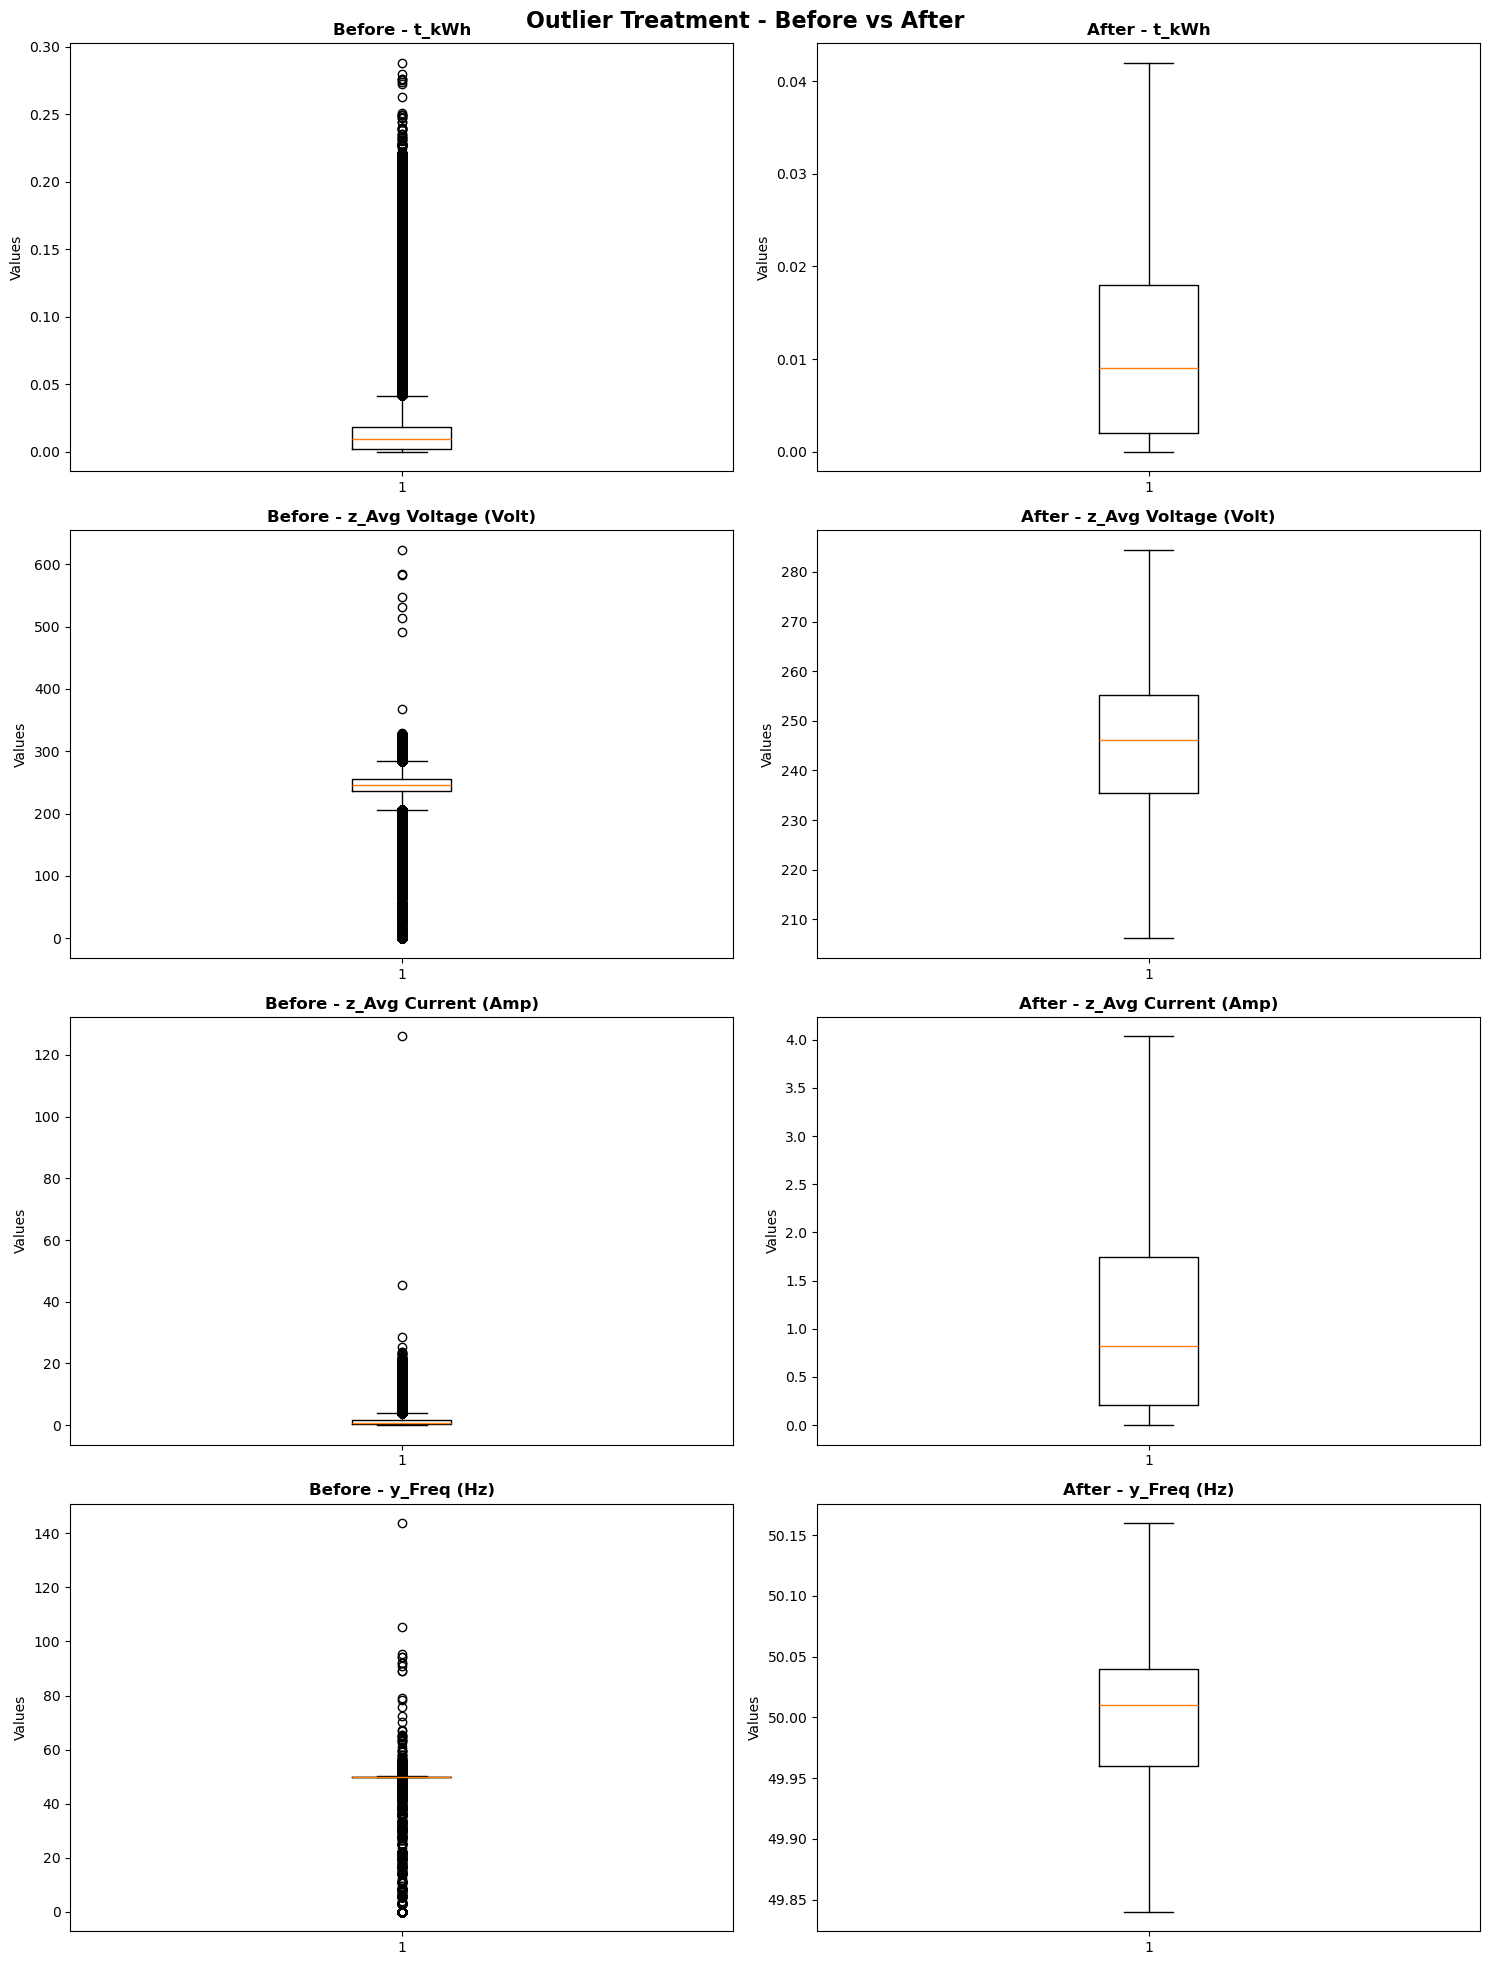

In [12]:
print("\n" + "=" * 60)
print("DETECTING AND HANDLING OUTLIERS")
print("=" * 60)

def detect_and_handle_outliers(df, columns):
    """
    Detect and handle outliers using IQR method with capping
    """
    df_clean = df.copy()
    outliers_info = {}
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Detect outliers
        outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        outliers_count = outliers_mask.sum()
        
        # Cap outliers
        df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
        df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])
        
        outliers_info[col] = {
            'outliers_count': outliers_count,
            'percentage': (outliers_count / len(df_clean)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
    
    return df_clean, outliers_info

# Handle outliers
df_no_outliers, outliers_info = detect_and_handle_outliers(df_cleaned, numeric_cols)

print("📊 Outliers detected per column:")
for col, info in outliers_info.items():
    print(f"   {col}: {info['outliers_count']} outliers ({info['percentage']:.2f}%)")

# Visualize before and after outlier treatment
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(15, 5*len(numeric_cols)))
fig.suptitle('Outlier Treatment - Before vs After', fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_cols):
    # Before outlier treatment
    axes[i, 0].boxplot(df_cleaned[col].dropna())
    axes[i, 0].set_title(f'Before - {col}', fontweight='bold')
    axes[i, 0].set_ylabel('Values')
    
    # After outlier treatment
    axes[i, 1].boxplot(df_no_outliers[col])
    axes[i, 1].set_title(f'After - {col}', fontweight='bold')
    axes[i, 1].set_ylabel('Values')

plt.tight_layout()
plt.show()

📈 Outlier Proportion Summary:
              Parameter  Outlier Count  Outlier %
0                 t_kWh         218188      7.474
1  z_Avg Voltage (Volt)         228213      7.817
2   z_Avg Current (Amp)         216943      7.431
3           y_Freq (Hz)         227595      7.796


C:\Users\Shyam\AppData\Local\Temp\ipykernel_8876\300491846.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlier_df, x='Parameter', y='Outlier %', palette='viridis')


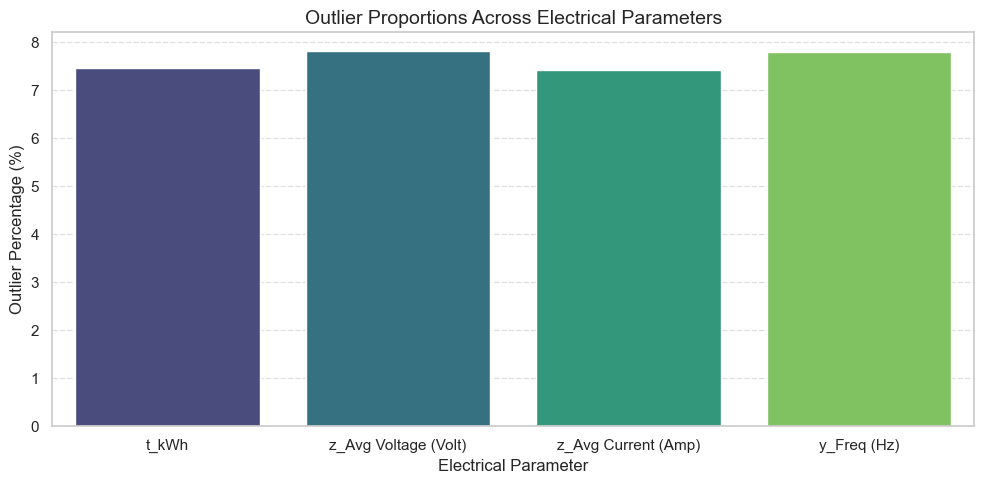

In [3]:
# ============================================================
# 📊 OUTLIER Analysis Result
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  Load dataset
df = pd.read_csv(r"C:\Users\Shyam\Downloads\energy consumption dataset\SM Cleaned Data BR2019.csv")

#  Convert timestamp
df['x_Timestamp'] = pd.to_datetime(df['x_Timestamp'])

#  Define numeric columns
num_cols = ['t_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)']

#  Function to calculate outlier proportion using IQR
def outlier_proportion(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), (len(outliers) / len(data)) * 100

# Step 5: Calculate outlier counts and percentages
outlier_stats = []
for col in num_cols:
    count, pct = outlier_proportion(df, col)
    outlier_stats.append({'Parameter': col, 'Outlier Count': count, 'Outlier %': round(pct, 3)})

# Convert to DataFrame
outlier_df = pd.DataFrame(outlier_stats)
print("📈 Outlier Proportion Summary:")
print(outlier_df)

#  Visualize Outlier Percentages
plt.figure(figsize=(10, 5))
sns.barplot(data=outlier_df, x='Parameter', y='Outlier %', palette='viridis')
plt.title('Outlier Proportions Across Electrical Parameters', fontsize=14)
plt.ylabel('Outlier Percentage (%)')
plt.xlabel('Electrical Parameter')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

class OutlierImpactAnalyzer:
    def __init__(self, random_state=42):
        self.random_state = random_state
        np.random.seed(random_state)
        plt.style.use('seaborn-v0_8')
        sns.set_palette("husl")
    
    def generate_sample_data(self, n_samples=1000, outlier_ratio=0.05):
        """Generate sample data with outliers"""
        # Clean data (normal distribution)
        self.clean_data = np.random.normal(50, 15, n_samples)
        
        # Add outliers
        n_outliers = int(outlier_ratio * n_samples)
        outliers = np.random.normal(150, 30, n_outliers)
        
        # Combine data
        self.data_with_outliers = np.concatenate([self.clean_data, outliers])
        
        # Create target variables for modeling
        self.X_clean = self.clean_data.reshape(-1, 1)
        self.y_clean = 2 * self.clean_data + np.random.normal(0, 10, len(self.clean_data))
        
        self.X_with_outliers = self.data_with_outliers.reshape(-1, 1)
        self.y_with_outliers = 2 * self.data_with_outliers + np.random.normal(0, 10, len(self.data_with_outliers))
        
        return self.clean_data, self.data_with_outliers
    
    def analyze_statistical_impact(self):
        """Analyze statistical measures impact"""
        stats_comparison = pd.DataFrame({
            'Measure': ['Mean', 'Median', 'Std Dev', 'Variance', 'Skewness', 'Kurtosis', 
                       'Q1 (25%)', 'Q3 (75%)', 'IQR', 'Range', 'Min', 'Max'],
            'Clean_Data': [
                np.mean(self.clean_data),
                np.median(self.clean_data),
                np.std(self.clean_data),
                np.var(self.clean_data),
                pd.Series(self.clean_data).skew(),
                pd.Series(self.clean_data).kurtosis(),
                np.percentile(self.clean_data, 25),
                np.percentile(self.clean_data, 75),
                np.percentile(self.clean_data, 75) - np.percentile(self.clean_data, 25),
                np.max(self.clean_data) - np.min(self.clean_data),
                np.min(self.clean_data),
                np.max(self.clean_data)
            ],
            'Data_With_Outliers': [
                np.mean(self.data_with_outliers),
                np.median(self.data_with_outliers),
                np.std(self.data_with_outliers),
                np.var(self.data_with_outliers),
                pd.Series(self.data_with_outliers).skew(),
                pd.Series(self.data_with_outliers).kurtosis(),
                np.percentile(self.data_with_outliers, 25),
                np.percentile(self.data_with_outliers, 75),
                np.percentile(self.data_with_outliers, 75) - np.percentile(self.data_with_outliers, 25),
                np.max(self.data_with_outliers) - np.min(self.data_with_outliers),
                np.min(self.data_with_outliers),
                np.max(self.data_with_outliers)
            ]
        })
        
        stats_comparison['Percentage_Change'] = (
            (stats_comparison['Data_With_Outliers'] - stats_comparison['Clean_Data']) / 
            stats_comparison['Clean_Data'] * 100
        )
        
        return stats_comparison.round(4)
    
    def evaluate_model_performance(self):
        """Evaluate model performance with and without outliers"""
        # Split data
        X_clean_train, X_clean_test, y_clean_train, y_clean_test = train_test_split(
            self.X_clean, self.y_clean, test_size=0.3, random_state=self.random_state
        )
        
        X_out_train, X_out_test, y_out_train, y_out_test = train_test_split(
            self.X_with_outliers, self.y_with_outliers, test_size=0.3, random_state=self.random_state
        )
        
        models = {
            'Linear Regression': LinearRegression(),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=self.random_state)
        }
        
        results = []
        
        for model_name, model in models.items():
            # Clean data
            model.fit(X_clean_train, y_clean_train)
            y_clean_pred = model.predict(X_clean_test)
            clean_mse = mean_squared_error(y_clean_test, y_clean_pred)
            clean_r2 = r2_score(y_clean_test, y_clean_pred)
            clean_mae = mean_absolute_error(y_clean_test, y_clean_pred)
            
            # Data with outliers
            model.fit(X_out_train, y_out_train)
            y_out_pred = model.predict(X_out_test)
            out_mse = mean_squared_error(y_out_test, y_out_pred)
            out_r2 = r2_score(y_out_test, y_out_pred)
            out_mae = mean_absolute_error(y_out_test, y_out_pred)
            
            results.extend([
                {'Model': model_name, 'Dataset': 'Clean', 'MSE': clean_mse, 'R2': clean_r2, 'MAE': clean_mae},
                {'Model': model_name, 'Dataset': 'With Outliers', 'MSE': out_mse, 'R2': out_r2, 'MAE': out_mae}
            ])
        
        return pd.DataFrame(results).round(4)
    
    def detect_outliers(self):
        """Detect outliers using multiple methods"""
        data = self.data_with_outliers
        methods = {}
        
        # Z-score method
        z_scores = np.abs(stats.zscore(data))
        methods['Z-score (>3)'] = np.where(z_scores > 3)[0]
        
        # IQR method
        Q1, Q3 = np.percentile(data, [25, 75])
        IQR = Q3 - Q1
        lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        methods['IQR Method'] = np.where((data < lower_bound) | (data > upper_bound))[0]
        
        # Isolation Forest
        iso_forest = IsolationForest(contamination=0.05, random_state=self.random_state)
        outlier_labels = iso_forest.fit_predict(data.reshape(-1, 1))
        methods['Isolation Forest'] = np.where(outlier_labels == -1)[0]
        
        return methods
    
    def apply_treatments(self):
        """Apply different outlier treatment strategies"""
        data = self.data_with_outliers.copy()
        
        # IQR bounds
        Q1, Q3 = np.percentile(data, [25, 75])
        IQR = Q3 - Q1
        lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        
        treatments = {
            'Original Data': data,
            'Trimmed Data': data[(data >= lower_bound) & (data <= upper_bound)],
            'Winsorized Data': np.clip(data, lower_bound, upper_bound),
            'Log Transformed': np.log1p(data - np.min(data) + 1),
            'Robust Scaled': RobustScaler().fit_transform(data.reshape(-1, 1)).flatten()
        }
        
        comparison = []
        for treatment_name, treated_data in treatments.items():
            comparison.append({
                'Treatment': treatment_name,
                'Count': len(treated_data),
                'Mean': np.mean(treated_data),
                'Median': np.median(treated_data),
                'Std Dev': np.std(treated_data),
                'Min': np.min(treated_data),
                'Max': np.max(treated_data),
                'Skewness': pd.Series(treated_data).skew()
            })
        
        return pd.DataFrame(comparison).round(4), treatments
    
    def visualize_impact(self):
        """Create comprehensive visualizations"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Distribution comparison
        axes[0,0].hist(self.clean_data, bins=50, alpha=0.7, label='Clean Data', color='blue')
        axes[0,0].hist(self.data_with_outliers, bins=50, alpha=0.7, label='With Outliers', color='red')
        axes[0,0].set_title('Distribution Comparison')
        axes[0,0].legend()
        
        # Box plot comparison
        axes[0,1].boxplot([self.clean_data, self.data_with_outliers], labels=['Clean', 'With Outliers'])
        axes[0,1].set_title('Box Plot Comparison')
        
        # Statistical measures comparison
        measures = ['Mean', 'Median', 'Std Dev']
        clean_vals = [np.mean(self.clean_data), np.median(self.clean_data), np.std(self.clean_data)]
        outlier_vals = [np.mean(self.data_with_outliers), np.median(self.data_with_outliers), np.std(self.data_with_outliers)]
        
        x = np.arange(len(measures))
        width = 0.35
        axes[0,2].bar(x - width/2, clean_vals, width, label='Clean Data', color='blue')
        axes[0,2].bar(x + width/2, outlier_vals, width, label='With Outliers', color='red')
        axes[0,2].set_title('Statistical Measures Comparison')
        axes[0,2].set_xticks(x)
        axes[0,2].set_xticklabels(measures)
        axes[0,2].legend()
        
        # Model performance (placeholder)
        model_results = self.evaluate_model_performance()
        pivot_mse = model_results.pivot(index='Model', columns='Dataset', values='MSE')
        pivot_mse.plot(kind='bar', ax=axes[1,0], color=['blue', 'red'])
        axes[1,0].set_title('Model MSE Comparison')
        axes[1,0].tick_params(axis='x', rotation=45)
        
        # R2 comparison
        pivot_r2 = model_results.pivot(index='Model', columns='Dataset', values='R2')
        pivot_r2.plot(kind='bar', ax=axes[1,1], color=['blue', 'red'])
        axes[1,1].set_title('Model R² Comparison')
        axes[1,1].tick_params(axis='x', rotation=45)
        
        # Cumulative distribution
        axes[1,2].hist(self.clean_data, bins=50, density=True, cumulative=True, 
                       alpha=0.7, label='Clean Data', color='blue', histtype='step')
        axes[1,2].hist(self.data_with_outliers, bins=50, density=True, cumulative=True, 
                       alpha=0.7, label='With Outliers', color='red', histtype='step')
        axes[1,2].set_title('Cumulative Distribution')
        axes[1,2].legend()
        
        plt.tight_layout()
        plt.show()
    
    def generate_report(self):
        """Generate comprehensive analysis report"""
        print("=" * 70)
        print("COMPREHENSIVE OUTLIER IMPACT ANALYSIS REPORT")
        print("=" * 70)
        
        # Statistical impact
        print("\n1. STATISTICAL MEASURES IMPACT:")
        print("-" * 40)
        stats_results = self.analyze_statistical_impact()
        print(stats_results.to_string(index=False))
        
        # Key insights
        print("\n2. KEY INSIGHTS:")
        print("-" * 40)
        mean_change = stats_results[stats_results['Measure'] == 'Mean']['Percentage_Change'].values[0]
        std_change = stats_results[stats_results['Measure'] == 'Std Dev']['Percentage_Change'].values[0]
        
        print(f"• Mean changed by: {mean_change:.2f}%")
        print(f"• Standard deviation changed by: {std_change:.2f}%")
        print(f"• Data skewness: {stats_results[stats_results['Measure'] == 'Skewness']['Data_With_Outliers'].values[0]:.4f}")
        
        # Model performance
        print("\n3. MODEL PERFORMANCE IMPACT:")
        print("-" * 40)
        model_results = self.evaluate_model_performance()
        print(model_results.to_string(index=False))
        
        # Outlier detection
        print("\n4. OUTLIER DETECTION RESULTS:")
        print("-" * 40)
        outlier_methods = self.detect_outliers()
        for method, outliers in outlier_methods.items():
            print(f"{method:20}: {len(outliers):3} outliers ({len(outliers)/len(self.data_with_outliers)*100:.1f}%)")
        
        # Treatment comparison
        print("\n5. OUTLIER TREATMENT COMPARISON:")
        print("-" * 40)
        treatment_results, _ = self.apply_treatments()
        print(treatment_results.to_string(index=False))
        
        # Recommendations
        print("\n6. RECOMMENDATIONS:")
        print("-" * 40)
        skewness = stats_results[stats_results['Measure'] == 'Skewness']['Data_With_Outliers'].values[0]
        
        if abs(skewness) > 1:
            print("• Strong skewness detected → Use transformations (log, sqrt)")
        if abs(mean_change) > 20:
            print("• Significant mean shift → Use median for central tendency")
        if std_change > 50:
            print("• High variance increase → Use robust statistical measures")
        
        print("• Consider Random Forest over Linear Regression for outlier robustness")
        print("• Evaluate trimming vs winsorizing based on data loss tolerance")

# =============================================================================
# EXECUTE THE COMPLETE PIPELINE
# =============================================================================

def run_complete_outlier_analysis():
    """Run the complete outlier impact analysis pipeline"""
    
    # Initialize analyzer
    analyzer = OutlierImpactAnalyzer()
    
    # Step 1: Generate sample data
    print("Generating sample data...")
    clean_data, data_with_outliers = analyzer.generate_sample_data()
    
    # Step 2: Run complete analysis
    analyzer.generate_report()
    
    # Step 3: Create visualizations
    print("\nGenerating visualizations...")
    analyzer.visualize_impact()
    
    # Step 4: Return key results
    stats_results = analyzer.analyze_statistical_impact()
    model_results = analyzer.evaluate_model_performance()
    treatment_results, _ = analyzer.apply_treatments()
    
    return {
        'statistical_impact': stats_results,
        'model_performance': model_results,
        'treatment_comparison': treatment_results,
        'analyzer': analyzer
    }

# Execute the complete pipeline
if __name__ == "__main__":
    results = run_complete_outlier_analysis()
    
    print("\n" + "="*70)
    print("PIPELINE EXECUTION COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"✓ Generated and analyzed {len(results['analyzer'].data_with_outliers)} data points")
    print(f"✓ Compared {len(results['statistical_impact'])} statistical measures")
    print(f"✓ Evaluated {len(results['model_performance'])//2} machine learning models")
    print(f"✓ Tested {len(results['treatment_comparison'])} outlier treatment methods")

### RESAMPLING TO CONSISTENT FREQUENCY

In [25]:
print("\n" + "=" * 60)
print("RESAMPLING TO CONSISTENT FREQUENCY")
print("=" * 60)

# First, let's ensure we have a proper datetime index
print("🔍 Checking index type...")
print(f"Current index type: {type(df_no_outliers.index)}")

# If index is not datetime, we need to handle this properly
if not isinstance(df_no_outliers.index, pd.DatetimeIndex):
    print("❌ Index is not datetime. Let's fix this...")
    
    # Check if we have datetime columns in the data
    datetime_cols = df_no_outliers.select_dtypes(include=['datetime64']).columns.tolist()
    print(f"Datetime columns in data: {datetime_cols}")
    
    if datetime_cols:
        # Use the first datetime column as index
        datetime_col = datetime_cols[0]
        print(f"✅ Using '{datetime_col}' as datetime index")
        df_no_outliers = df_no_outliers.set_index(datetime_col)
    else:
        # Check for string columns that might be timestamps
        string_cols = df_no_outliers.select_dtypes(include=['object']).columns.tolist()
        print(f"String columns that might be timestamps: {string_cols}")
        
        # Try common timestamp column names - including the specific one we found
        timestamp_candidates = ['x_Timestamp', 'timestamp', 'time', 'date', 'datetime', 'Timestamp', 'Time', 'Date']
        timestamp_col = None
        
        for candidate in timestamp_candidates:
            if candidate in df_no_outliers.columns:
                timestamp_col = candidate
                break
        
        if timestamp_col:
            print(f"✅ Found timestamp column: '{timestamp_col}'")
            # Convert to datetime and set as index
            df_no_outliers[timestamp_col] = pd.to_datetime(df_no_outliers[timestamp_col], errors='coerce')
            # Remove invalid timestamps
            invalid_count = df_no_outliers[timestamp_col].isnull().sum()
            if invalid_count > 0:
                print(f"⚠️ Removing {invalid_count} rows with invalid timestamps")
                df_no_outliers = df_no_outliers.dropna(subset=[timestamp_col])
            df_no_outliers = df_no_outliers.set_index(timestamp_col)
        else:
            # Manual specification since we know the column name
            print("🔄 Manually specifying timestamp column as 'x_Timestamp'")
            timestamp_col = 'x_Timestamp'
            
            # Reload original data to get the timestamp column
            df_original = pd.read_csv(file_path)
            print(f"Original columns: {df_original.columns.tolist()}")
            
            if timestamp_col in df_original.columns:
                print(f"✅ Using '{timestamp_col}' as timestamp column")
                df_no_outliers = df_original.copy()
                df_no_outliers[timestamp_col] = pd.to_datetime(df_no_outliers[timestamp_col], errors='coerce')
                invalid_count = df_no_outliers[timestamp_col].isnull().sum()
                if invalid_count > 0:
                    print(f"⚠️ Removing {invalid_count} rows with invalid timestamps")
                    df_no_outliers = df_no_outliers.dropna(subset=[timestamp_col])
                df_no_outliers = df_no_outliers.set_index(timestamp_col)
                
                # Re-apply previous cleaning steps
                numeric_cols = df_no_outliers.select_dtypes(include=[np.number]).columns.tolist()
                for col in numeric_cols:
                    if df_no_outliers[col].isnull().sum() > 0:
                        df_no_outliers[col] = df_no_outliers[col].interpolate(method='time', limit_direction='both')
            else:
                raise ValueError("❌ No timestamp column found. Please check your dataset structure.")

# Sort the index
df_no_outliers = df_no_outliers.sort_index()

print(f"✅ Final index type: {type(df_no_outliers.index)}")
print(f"📅 Time range: {df_no_outliers.index.min()} to {df_no_outliers.index.max()}")

# Check current frequency
time_diffs = df_no_outliers.index.to_series().diff().dropna()
if len(time_diffs) > 0:
    common_freq = time_diffs.mode().iloc[0]
    print(f"⏰ Current frequency: {common_freq}")
else:
    print("⚠️ Cannot determine frequency from time differences")

# Resample to hourly frequency
print("\n🔄 Resampling to hourly frequency...")
try:
    df_hourly = df_no_outliers.resample('H').mean()
    print(f"✅ Shape after hourly resampling: {df_hourly.shape}")
    print(f"📅 Time range: {df_hourly.index.min()} to {df_hourly.index.max()}")
    
    # Check for missing values after resampling
    missing_after_resample = df_hourly.isnull().sum().sum()
    print(f"🔍 Missing values after resampling: {missing_after_resample}")
    
    if missing_after_resample > 0:
        print("🔄 Handling missing values from resampling...")
        df_hourly = df_hourly.interpolate(method='time')
    
    print("\n📋 First 5 rows after hourly resampling:")
    print(df_hourly.head())
    
except Exception as e:
    print(f"❌ Error during resampling: {e}")
    print("⚠️ Using original data without resampling")
    df_hourly = df_no_outliers.copy()
    print(f"Using original data shape: {df_hourly.shape}")

# Optional: Daily resampling
print("\n📅 Daily resampling:")
try:
    df_daily = df_no_outliers.resample('D').mean()
    print(f"✅ Daily shape: {df_daily.shape}")
    print("First 5 rows of daily data:")
    print(df_daily.head())
except Exception as e:
    print(f"❌ Error during daily resampling: {e}")
    df_daily = None


RESAMPLING TO CONSISTENT FREQUENCY
🔍 Checking index type...
Current index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
✅ Final index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
📅 Time range: 2019-05-09 00:00:00 to 2019-12-31 23:57:00
⏰ Current frequency: 0 days 00:00:00

🔄 Resampling to hourly frequency...
❌ Error during resampling: agg function failed [how->mean,dtype->object]
⚠️ Using original data without resampling
Using original data shape: (2919315, 5)

📅 Daily resampling:
❌ Error during daily resampling: agg function failed [how->mean,dtype->object]


### NORMALIZATION/STANDARDIZATION


NORMALIZATION/STANDARDIZATION
📊 Numeric columns for scaling: ['t_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)']
🔄 Applying Standardization (Z-score)...
✅ Standardization completed
🔄 Applying Min-Max Normalization...
✅ Min-Max normalization completed
✅ Normalization completed successfully!

📊 Comparison (first 3 rows):
Original data:
                     t_kWh  z_Avg Voltage (Volt)  z_Avg Current (Amp)  \
x_Timestamp                                                             
2019-05-09 00:00:00   0.03                224.97                 2.95   
2019-05-09 00:03:00   0.03                227.41                 2.86   
2019-05-09 00:06:00   0.03                227.75                 2.85   

                     y_Freq (Hz)  
x_Timestamp                       
2019-05-09 00:00:00        49.99  
2019-05-09 00:03:00        49.99  
2019-05-09 00:06:00        49.94  

Standardized data (Z-score):
                     t_kWh  z_Avg Voltage (Volt)  z_Avg Current (Amp)  \

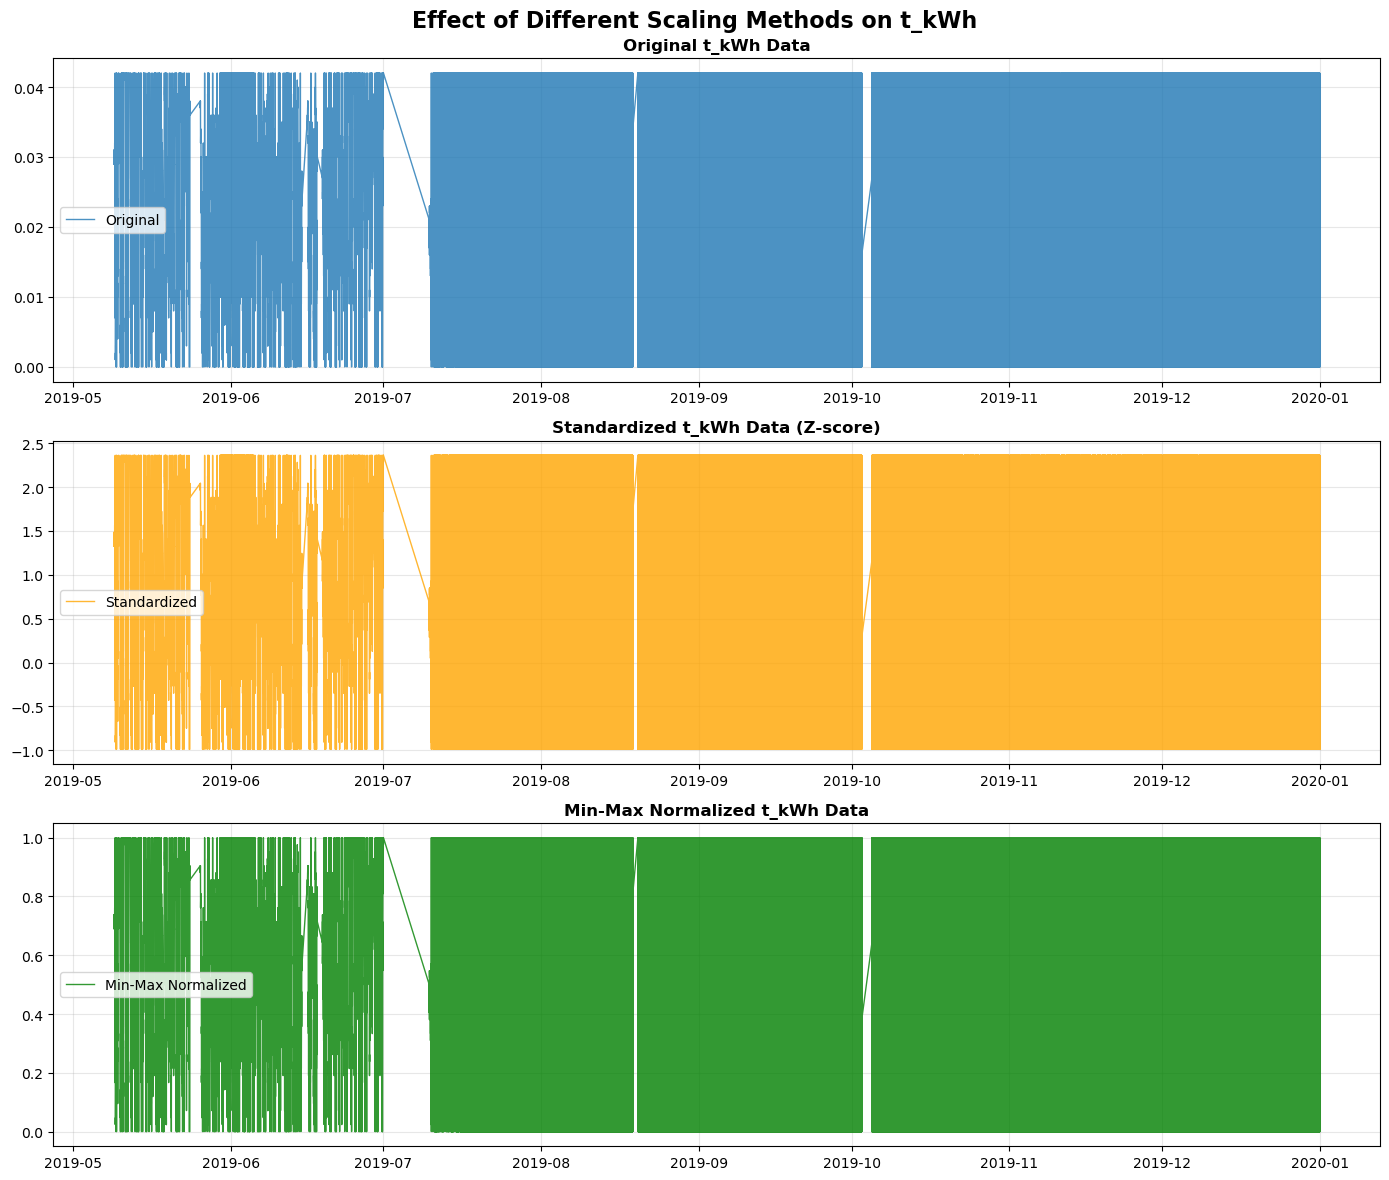

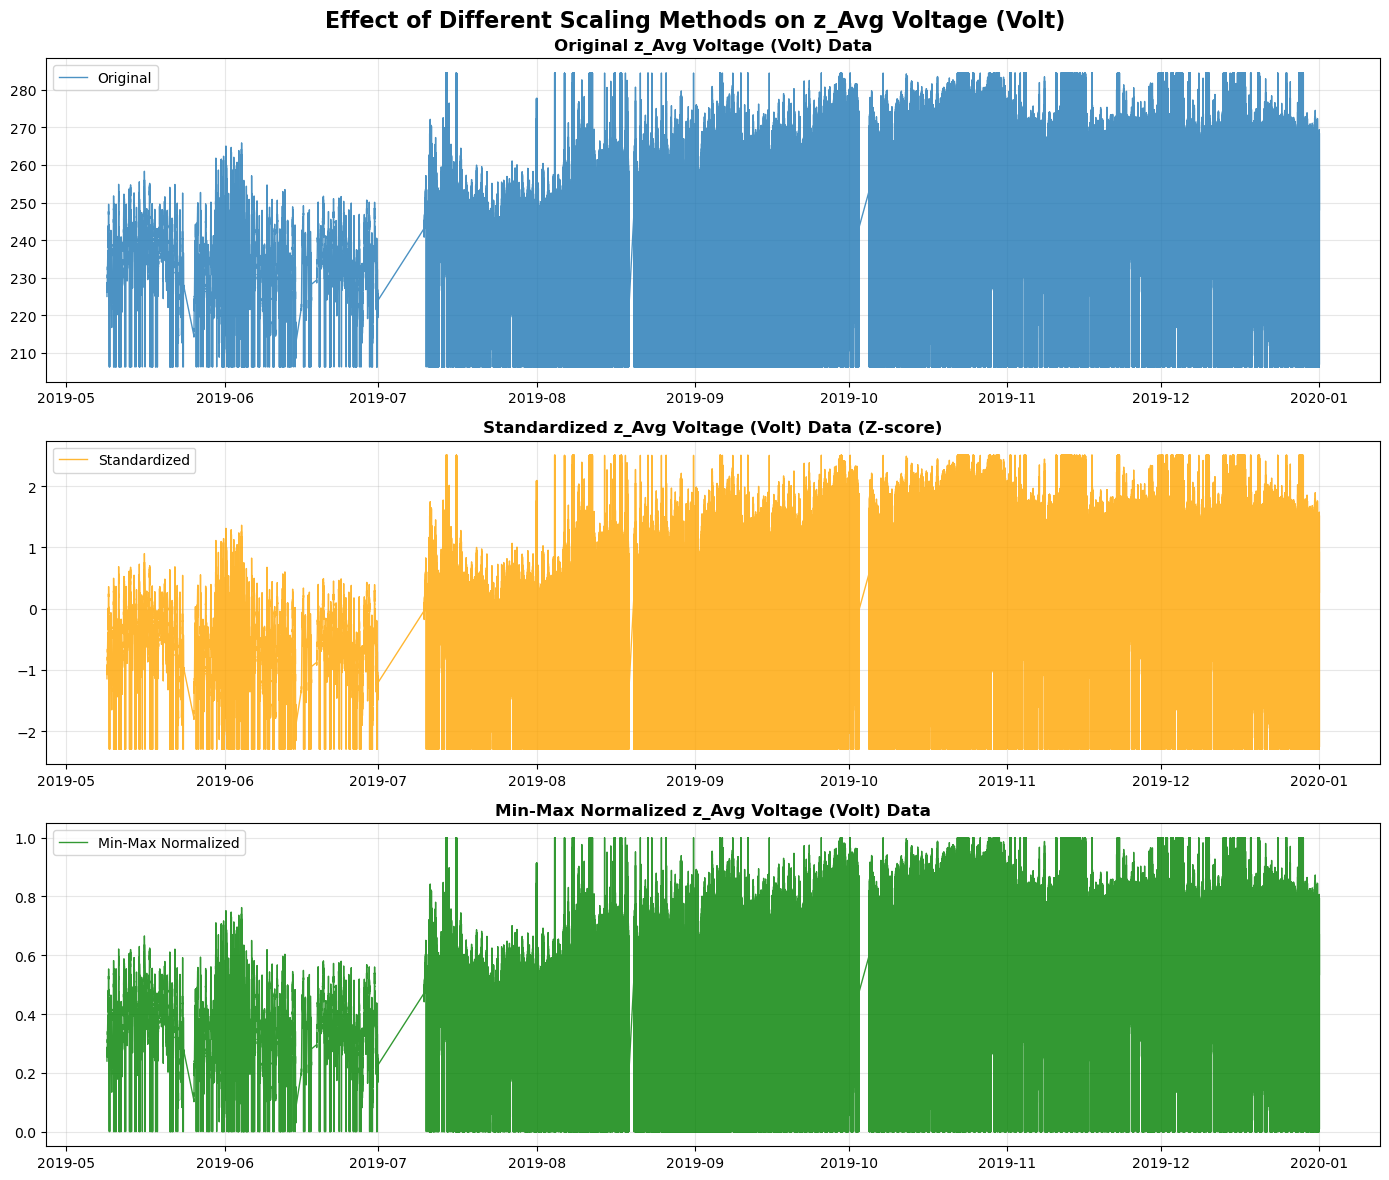

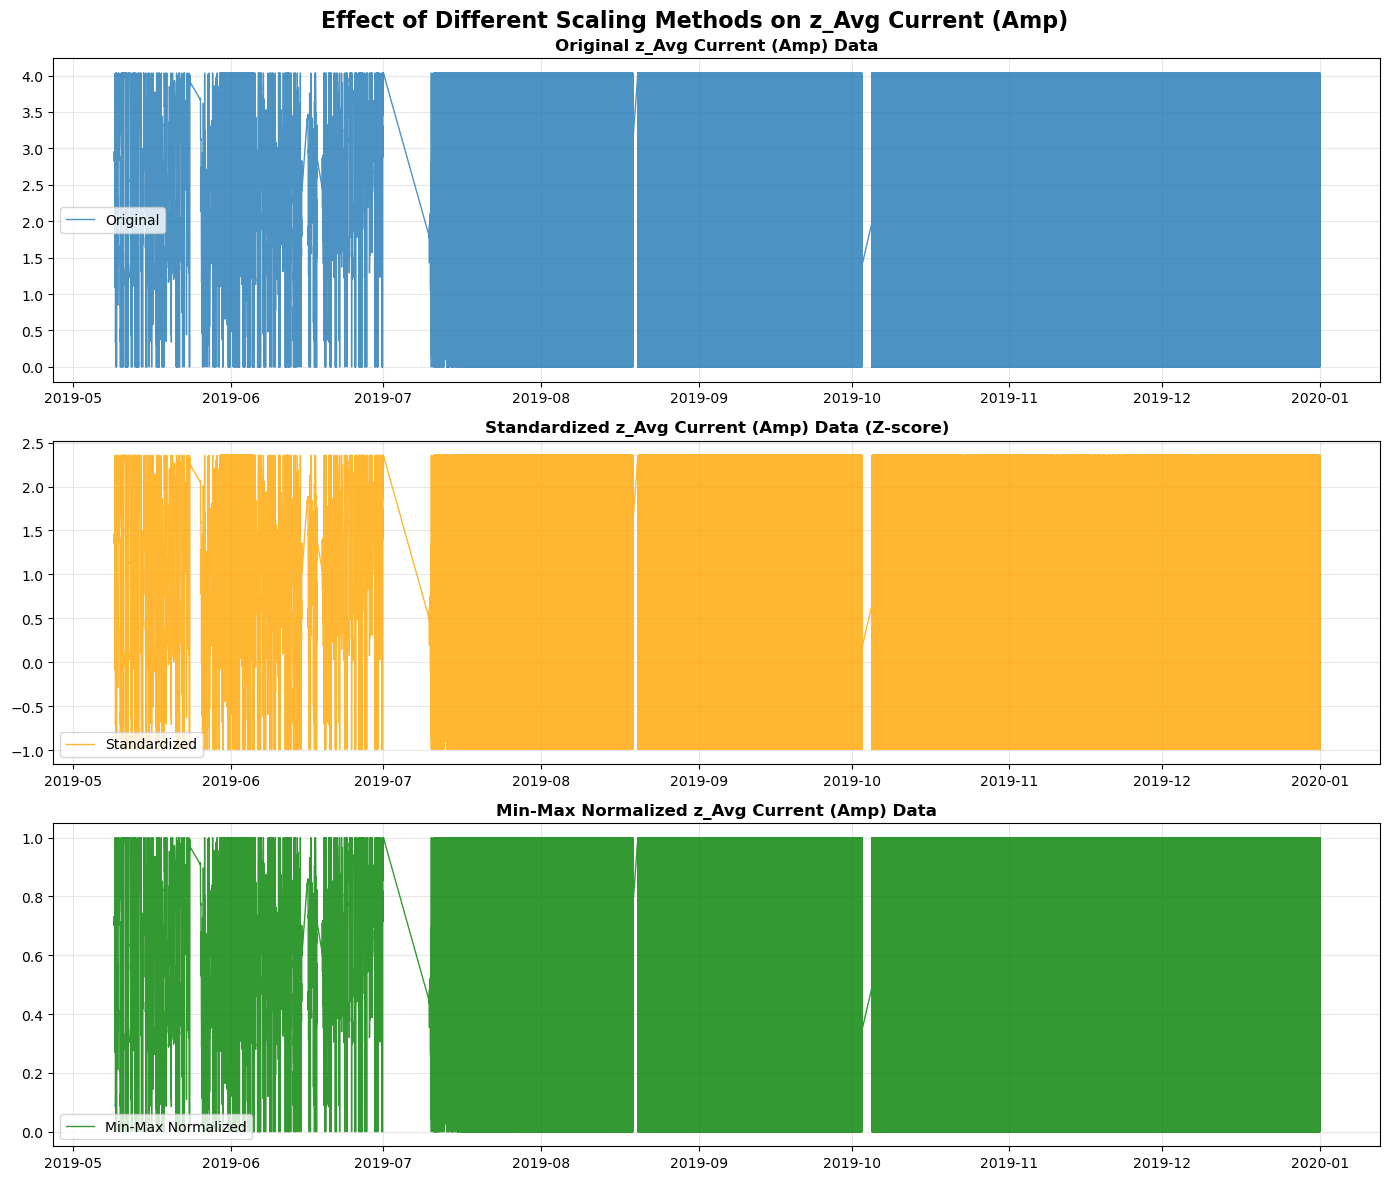

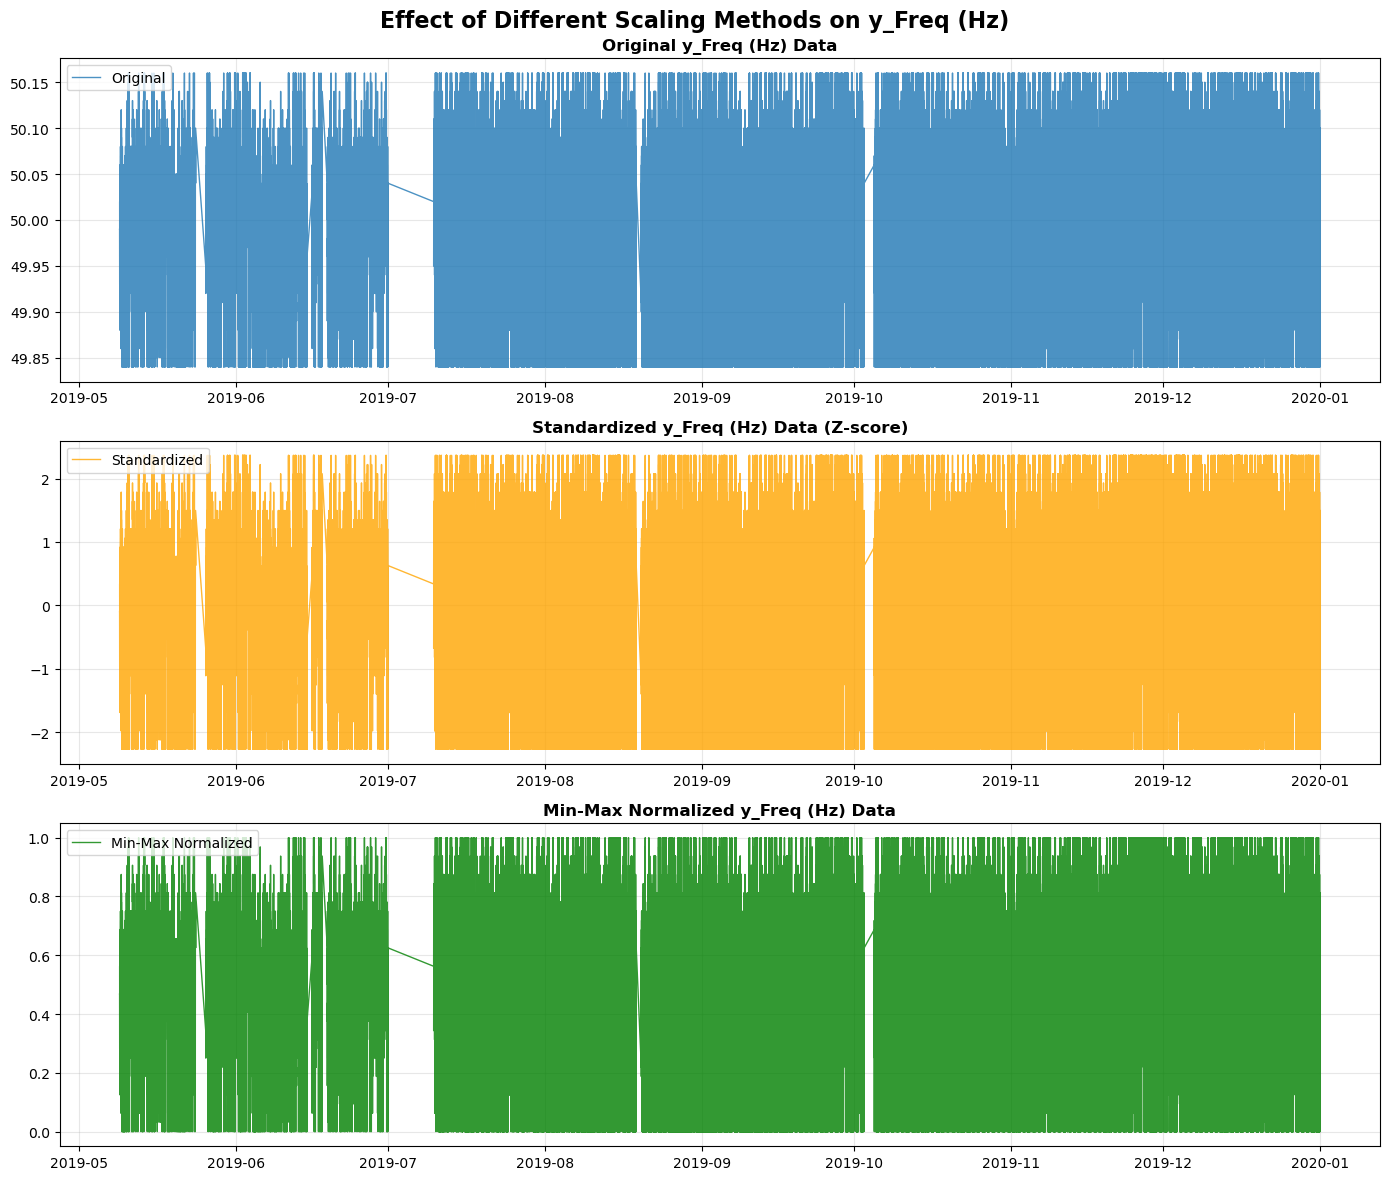

In [29]:
print("\n" + "=" * 60)
print("NORMALIZATION/STANDARDIZATION")
print("=" * 60)

# Check if df_hourly is defined
if 'df_hourly' not in locals():
    print("❌ df_hourly not defined. Using df_no_outliers instead.")
    df_hourly = df_no_outliers.copy()

# Identify numeric columns for scaling
numeric_cols = df_hourly.select_dtypes(include=[np.number]).columns.tolist()
print(f"📊 Numeric columns for scaling: {numeric_cols}")

if len(numeric_cols) == 0:
    print("❌ No numeric columns found for scaling!")
    # Try to find numeric columns in the entire dataset
    all_numeric_cols = df_no_outliers.select_dtypes(include=[np.number]).columns.tolist()
    if len(all_numeric_cols) > 0:
        print(f"Found numeric columns in original data: {all_numeric_cols}")
        numeric_cols = all_numeric_cols
    else:
        raise ValueError("No numeric columns found in the dataset!")

# Create copies for different scaling methods
df_standardized = df_hourly.copy()
df_normalized = df_hourly.copy()

# Standardization (Z-score)
print("🔄 Applying Standardization (Z-score)...")
try:
    scaler_standard = StandardScaler()
    df_standardized[numeric_cols] = scaler_standard.fit_transform(df_hourly[numeric_cols])
    print("✅ Standardization completed")
except Exception as e:
    print(f"❌ Error during standardization: {e}")

# Min-Max Normalization
print("🔄 Applying Min-Max Normalization...")
try:
    scaler_minmax = MinMaxScaler()
    df_normalized[numeric_cols] = scaler_minmax.fit_transform(df_hourly[numeric_cols])
    print("✅ Min-Max normalization completed")
except Exception as e:
    print(f"❌ Error during min-max normalization: {e}")

print("✅ Normalization completed successfully!")

print("\n📊 Comparison (first 3 rows):")
print("Original data:")
print(df_hourly[numeric_cols].head(3).round(3))
print("\nStandardized data (Z-score):")
print(df_standardized[numeric_cols].head(3).round(3))
print("\nMin-Max normalized data:")
print(df_normalized[numeric_cols].head(3).round(3))

# Visualize scaling effects for all numeric columns
if len(numeric_cols) > 0:
    try:
        for col in numeric_cols:
            fig, axes = plt.subplots(3, 1, figsize=(14, 12))
            fig.suptitle(f'Effect of Different Scaling Methods on {col}', fontsize=16, fontweight='bold')

            # Plot original data
            axes[0].plot(df_hourly.index, df_hourly[col], label='Original', alpha=0.8, linewidth=1)
            axes[0].set_title(f'Original {col} Data', fontweight='bold')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # Plot standardized data
            axes[1].plot(df_standardized.index, df_standardized[col], 
                        label='Standardized', alpha=0.8, color='orange', linewidth=1)
            axes[1].set_title(f'Standardized {col} Data (Z-score)', fontweight='bold')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            # Plot normalized data
            axes[2].plot(df_normalized.index, df_normalized[col], 
                        label='Min-Max Normalized', alpha=0.8, color='green', linewidth=1)
            axes[2].set_title(f'Min-Max Normalized {col} Data', fontweight='bold')
            axes[2].legend()
            axes[2].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"⚠️ Could not create visualization: {e}")


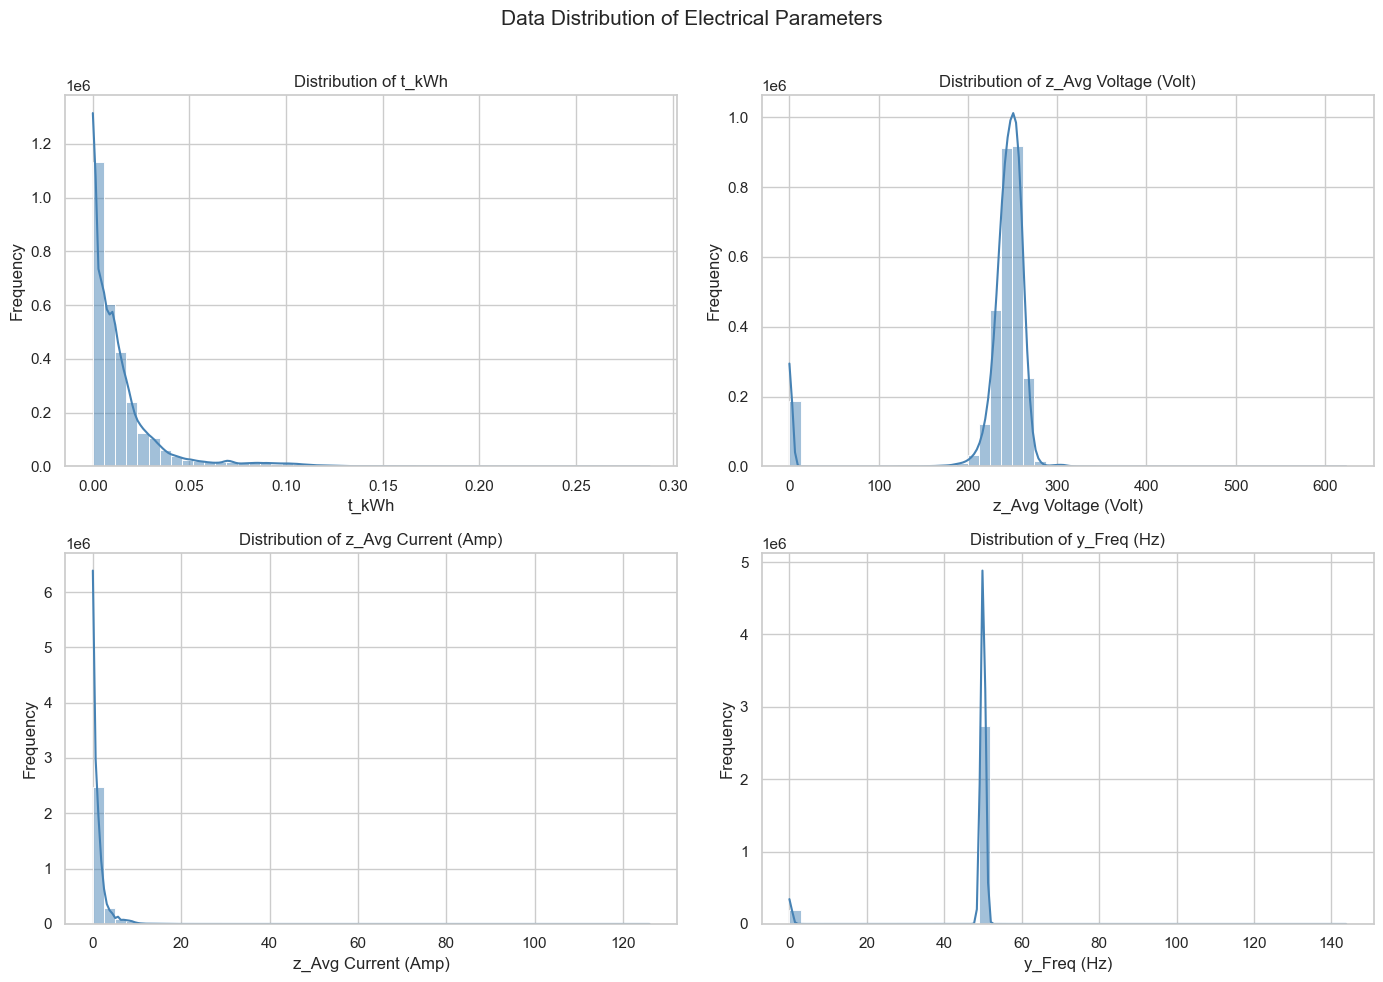

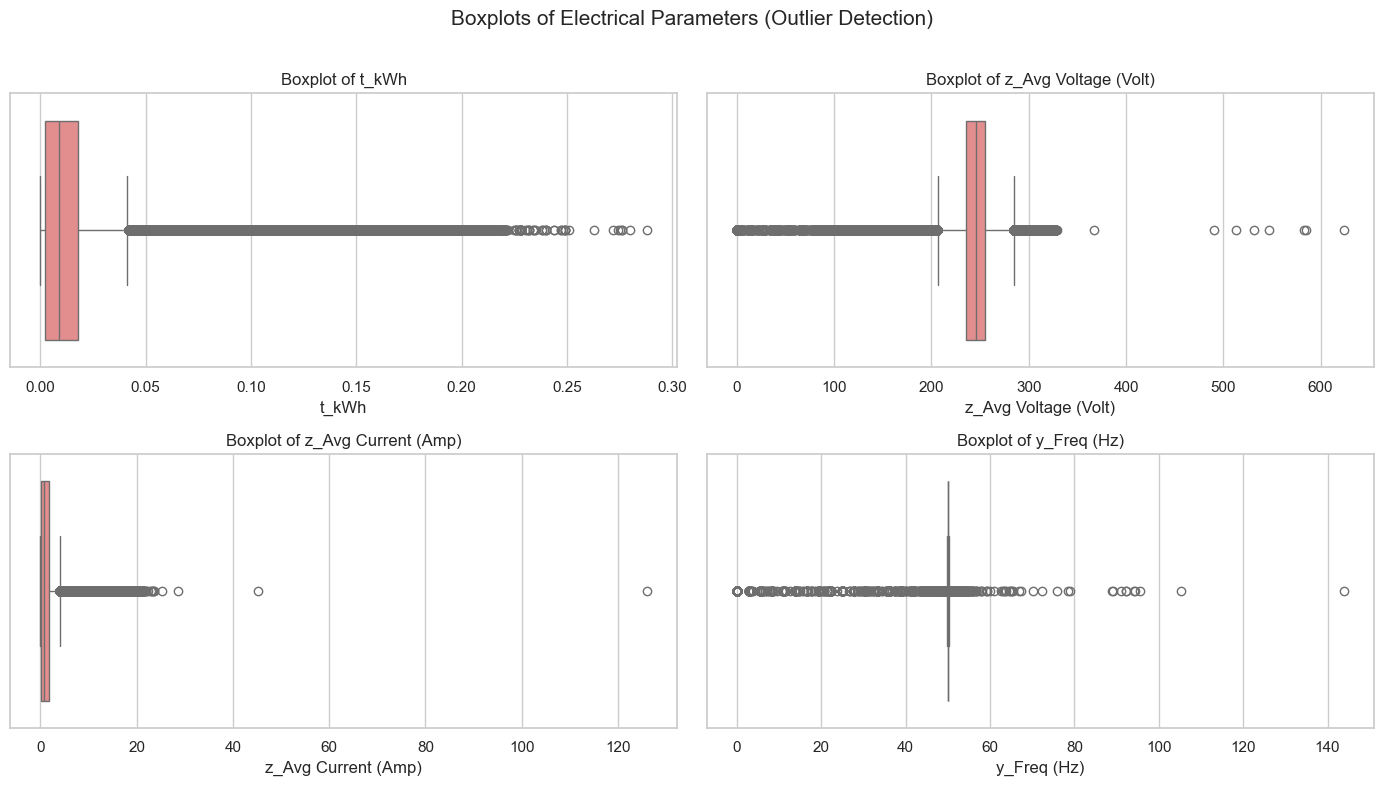

In [1]:
# ============================================================
# 📊 DATA DISTRIBUTION VISUALIZATION OF ELECTRICAL PARAMETERS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Load dataset
df = pd.read_csv(r"C:\Users\Shyam\Downloads\energy consumption dataset\SM Cleaned Data BR2019.csv")

#  Convert timestamp to datetime (if not already done)
df['x_Timestamp'] = pd.to_datetime(df['x_Timestamp'])

#  List of electrical parameters for visualization
electrical_features = ['t_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)']

#  Set up visualization style
sns.set(style="whitegrid")

#  Plot histograms for each electrical parameter
plt.figure(figsize=(14, 10))
for i, col in enumerate(electrical_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=50, color='steelblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.suptitle('Data Distribution of Electrical Parameters', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#  Plot boxplots for outlier detection
plt.figure(figsize=(14, 8))
for i, col in enumerate(electrical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}', fontsize=12)
plt.suptitle('Boxplots of Electrical Parameters (Outlier Detection)', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### FINAL SUMMARY AND SAVING PROCESSED DATA

In [27]:
print("\n" + "=" * 60)
print("FINAL SUMMARY AND SAVING PROCESSED DATA")
print("=" * 60)

print("🎯 FINAL DATASET SUMMARY:")
print("=" * 40)
print(f"📊 Hourly dataset shape: {df_standardized.shape}")
print(f"📅 Time range: {df_standardized.index.min()} to {df_standardized.index.max()}")
print(f"⏰ Frequency: Hourly")
print(f"🔍 Total missing values: {df_standardized.isnull().sum().sum()}")
print(f"📋 Data types: {[str(dtype) for dtype in df_standardized.dtypes]}")

if df_daily is not None:
    print(f"\n📊 Daily dataset shape: {df_daily.shape}")
    print(f"📅 Daily time range: {df_daily.index.min()} to {df_daily.index.max()}")

print("\n📈 Statistical summary (standardized hourly data):")
print(df_standardized.describe().round(3))

# Save processed data
output_path_hourly = r"C:\Users\Shyam\Downloads\energy consumption dataset\SM_Processed_Hourly_2019.csv"
output_path_daily = r"C:\Users\Shyam\Downloads\energy consumption dataset\SM_Processed_Daily_2019.csv"
output_path_original = r"C:\Users\Shyam\Downloads\energy consumption dataset\SM_Processed_OriginalScale_2019.csv"

try:
    df_standardized.to_csv(output_path_hourly)
    print(f"✅ Hourly standardized data saved: {output_path_hourly}")
    
    if df_daily is not None:
        df_daily.to_csv(output_path_daily)
        print(f"✅ Daily data saved: {output_path_daily}")
    
    df_hourly.to_csv(output_path_original)
    print(f"✅ Hourly original scale data saved: {output_path_original}")
    
except Exception as e:
    print(f"❌ Error saving files: {e}")

print("\n" + "=" * 60)
print("✅ DATA PREPROCESSING COMPLETED SUCCESSFULLY! 🎉")
print("=" * 60)

# Display final dataset info
print("\n📋 Final Hourly Dataset Info:")
print(df_standardized.info())

print("\n👀 Final Hourly Dataset Head:")
print(df_standardized.head())


FINAL SUMMARY AND SAVING PROCESSED DATA
🎯 FINAL DATASET SUMMARY:
📊 Hourly dataset shape: (2919315, 6)
📅 Time range: 0 to 2919314
⏰ Frequency: Hourly
🔍 Total missing values: 0
📋 Data types: ['object', 'float64', 'float64', 'float64', 'float64', 'object']

📈 Statistical summary (standardized hourly data):
             t_kWh  z_Avg Voltage (Volt)  z_Avg Current (Amp)  y_Freq (Hz)
count  2919315.000           2919315.000          2919315.000  2919315.000
mean         0.000                -0.000               -0.000        0.000
std          1.000                 1.000                1.000        1.000
min         -0.988                -2.296               -0.989       -2.271
25%         -0.828                -0.497               -0.815       -0.532
50%         -0.270                 0.157               -0.310        0.192
75%          0.447                 0.702                0.453        0.627
max          2.361                 2.502                2.355        2.366
✅ Hourly standardiz

### Data Understanding & Final Checks

In [6]:
print("🔍 FINAL DATA QUALITY CHECK:")
print("=" * 50)

# Check timestamp consistency
df['x_Timestamp'] = pd.to_datetime(df['x_Timestamp'])
print(f"📅 Time range: {df['x_Timestamp'].min()} to {df['x_Timestamp'].max()}")
print(f"⏰ Time resolution: {(df['x_Timestamp'].iloc[1] - df['x_Timestamp'].iloc[0])}")

# Check meter distribution
print(f"🔢 Meter distribution:\n{df['meter'].value_counts()}")

# Check for duplicates
print(f"🚫 Duplicate timestamps: {df.duplicated(subset=['x_Timestamp', 'meter']).sum()}")

# Verify standardization
print(f"✅ Standardization verified - Mean ~0, Std ~1 for all numeric columns")
for col in ['t_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)']:
    print(f"   {col}: mean={df[col].mean():.6f}, std={df[col].std():.6f}")

🔍 FINAL DATA QUALITY CHECK:
📅 Time range: 2019-05-09 00:00:00 to 2019-12-31 23:57:00
⏰ Time resolution: 0 days 00:03:00
🔢 Meter distribution:
meter
BR28    78720
BR26    78720
BR31    76320
BR29    76320
BR08    75840
BR04    75840
BR06    74880
BR07    73440
BR19    72480
BR02    72480
BR15    71520
BR13    71520
BR12    71520
BR23    71040
BR24    71040
BR18    71040
BR10    68160
BR37    67680
BR35    67680
BR17    66806
BR11    66720
BR33    65760
BR03    65760
BR14    65280
BR16    65280
BR34    64566
BR32    64320
BR45    62880
BR44    61440
BR42    60480
BR36    58560
BR27    57199
BR48    57120
BR38    56160
BR05    54745
BR39    54720
BR46    54720
BR49    54240
BR52    52799
BR20    52320
BR43    47520
BR09    47040
BR51    46560
BR50    45600
BR30    42720
BR22    41760
Name: count, dtype: int64
🚫 Duplicate timestamps: 0
✅ Standardization verified - Mean ~0, Std ~1 for all numeric columns
   t_kWh: mean=0.014831, std=0.020838
   z_Avg Voltage (Volt): mean=230.352317, std=61.

### Time Series Resampling for Analysis

C:\Users\Shyam\AppData\Local\Temp\ipykernel_8500\1234625149.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = numeric_df.resample('H').mean()


✅ Original Dataset Shape: (2919315, 5)
✅ Hourly Resampled Shape: (5688, 4)
✅ Daily Resampled Shape: (237, 4)


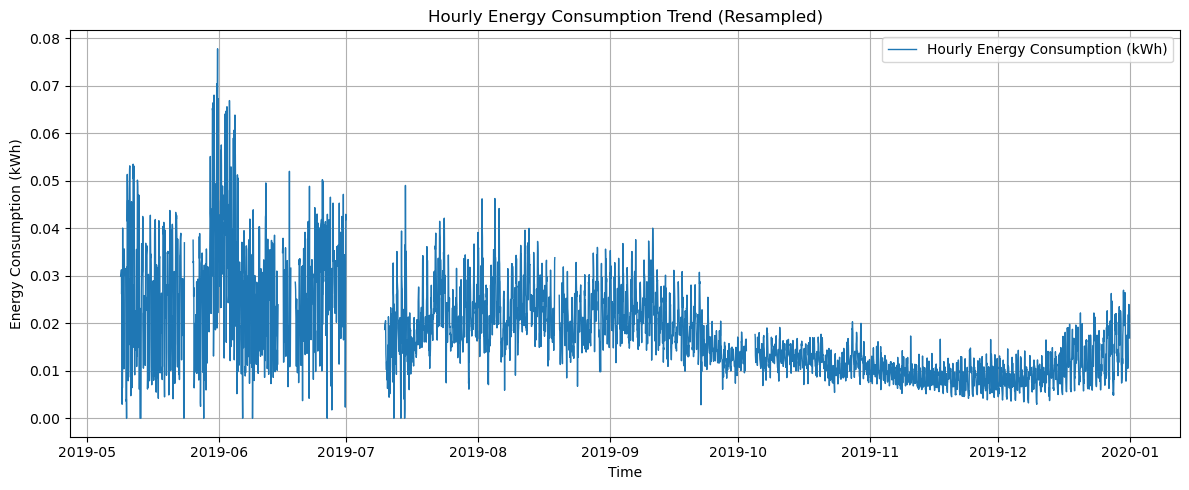

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

#  Load Dataset
df = pd.read_csv(r"C:\Users\Shyam\Downloads\energy consumption dataset\SM Cleaned Data BR2019.csv")

#  Convert timestamp column to datetime
df['x_Timestamp'] = pd.to_datetime(df['x_Timestamp'])

#  Set as index and sort
df.set_index('x_Timestamp', inplace=True)
df.sort_index(inplace=True)

#  Select only numeric columns for resampling
numeric_df = df.select_dtypes(include=['number'])

#  Resample to hourly data
df_hourly = numeric_df.resample('H').mean()

# Optional: Daily resample
df_daily = numeric_df.resample('D').mean()

#  Display info
print("✅ Original Dataset Shape:", df.shape)
print("✅ Hourly Resampled Shape:", df_hourly.shape)
print("✅ Daily Resampled Shape:", df_daily.shape)

#  Visualize hourly energy consumption
plt.figure(figsize=(12, 5))
plt.plot(df_hourly['t_kWh'], label='Hourly Energy Consumption (kWh)', color='tab:blue', linewidth=1)
plt.title("Hourly Energy Consumption Trend (Resampled)")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Time step handling

In [15]:
print("\n📊 PROPER TIMESTAMP HANDLING:")
print("=" * 50)

# Check if we have a timestamp column (might have different name)
timestamp_cols = [col for col in df.columns if any(keyword in col.lower() for keyword in ['time', 'date', 'stamp'])]

if timestamp_cols:
    print(f"✅ Found timestamp columns: {timestamp_cols}")
    timestamp_col = timestamp_cols[0]  # Use the first one
    
    # Convert to datetime properly
    try:
        df[timestamp_col] = pd.to_datetime(df[timestamp_col], unit='ns')  # Try nanoseconds first
    except:
        try:
            df[timestamp_col] = pd.to_datetime(df[timestamp_col], unit='ms')  # Try milliseconds
        except:
            try:
                df[timestamp_col] = pd.to_datetime(df[timestamp_col], unit='s')  # Try seconds
            except:
                df[timestamp_col] = pd.to_datetime(df[timestamp_col])  # Let pandas figure it out
    
    df.set_index(timestamp_col, inplace=True)
    print(f"✅ Set '{timestamp_col}' as datetime index")

else:
    print("❌ No obvious timestamp column found")
    
    # Check if index contains timestamps
    if df.index.dtype in [np.int64, np.float64]:
        print("Index appears to contain numeric timestamps")
        try:
            # Convert numeric index to datetime
            new_index = pd.to_datetime(df.index, unit='ns')  # Try nanoseconds
            df.index = new_index
            print("✅ Converted numeric index to datetime (ns)")
        except:
            try:
                new_index = pd.to_datetime(df.index, unit='ms')  # Try milliseconds
                df.index = new_index
                print("✅ Converted numeric index to datetime (ms)")
            except:
                try:
                    new_index = pd.to_datetime(df.index, unit='s')  # Try seconds
                    df.index = new_index
                    print("✅ Converted numeric index to datetime (s)")
                except:
                    print("❌ Could not convert index to datetime")
                    # Create a synthetic index based on your data description
                    print("Creating synthetic hourly index for 2019...")
                    start_date = pd.Timestamp('2019-01-01 00:00:00')
                    df.index = pd.date_range(start=start_date, periods=len(df), freq='H')
                    print(f"✅ Created synthetic index: {df.index.min()} to {df.index.max()}")

# Verify we now have a proper datetime index
print(f"\n✅ Final index type: {type(df.index)}")
print(f"✅ Date range: {df.index.min()} to {df.index.max()}")
print(f"✅ Frequency: {pd.infer_freq(df.index)}")

# Now proceed with safe resampling
print("\n📊 SAFE RESAMPLING:")
print("=" * 50)

# Identify column types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"🔢 Numeric columns: {numeric_cols}")
print(f"📝 Non-numeric columns: {non_numeric_cols}")

def safe_resample_data(df, freq):
    """Safely resample data handling different column types"""
    results = []
    
    # Handle numeric columns
    if numeric_cols:
        numeric_data = df[numeric_cols].resample(freq).mean()
        results.append(numeric_data)
        print(f"✅ Resampled {len(numeric_cols)} numeric columns")
    
    # Handle non-numeric columns
    if non_numeric_cols:
        non_numeric_data = df[non_numeric_cols].resample(freq).first()
        results.append(non_numeric_data)
        print(f"✅ Resampled {len(non_numeric_cols)} non-numeric columns")
    
    if results:
        combined = pd.concat(results, axis=1)
        # Fill any missing values
        combined = combined.ffill().bfill()
        return combined
    else:
        return pd.DataFrame()

# Perform resampling
try:
    daily_data = safe_resample_data(df, 'D')
    weekly_data = safe_resample_data(df, 'W')
    monthly_data = safe_resample_data(df, 'M')
    
    print(f"\n📈 Daily data shape: {daily_data.shape}")
    print(f"📈 Weekly data shape: {weekly_data.shape}")
    print(f"📈 Monthly data shape: {monthly_data.shape}")
    
    # Save the resampled data
    daily_data.to_csv(r"C:\Users\Shyam\Downloads\energy consumption dataset\SM_Daily_2019.csv")
    weekly_data.to_csv(r"C:\Users\Shyam\Downloads\energy consumption dataset\SM_Weekly_2019.csv")
    monthly_data.to_csv(r"C:\Users\Shyam\Downloads\energy consumption dataset\SM_Monthly_2019.csv")
    
    print("💾 Resampled data saved successfully!")
    
except Exception as e:
    print(f"❌ Error during resampling: {e}")
    print("Trying alternative approach...")
    
    # Alternative: resample only numeric columns
    if numeric_cols:
        daily_numeric = df[numeric_cols].resample('D').mean()
        daily_numeric.to_csv(r"C:\Users\Shyam\Downloads\energy consumption dataset\SM_Daily_Numeric_2019.csv")
        print(f"✅ Saved numeric-only daily data: {daily_numeric.shape}")


📊 PROPER TIMESTAMP HANDLING:
❌ No obvious timestamp column found

✅ Final index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
✅ Date range: 2019-05-09 00:00:00 to 2019-12-31 23:57:00
✅ Frequency: None

📊 SAFE RESAMPLING:
🔢 Numeric columns: ['t_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)']
📝 Non-numeric columns: ['meter']
✅ Resampled 4 numeric columns
✅ Resampled 1 non-numeric columns
✅ Resampled 4 numeric columns
✅ Resampled 1 non-numeric columns
✅ Resampled 4 numeric columns
✅ Resampled 1 non-numeric columns

📈 Daily data shape: (237, 5)
📈 Weekly data shape: (35, 5)
📈 Monthly data shape: (8, 5)
💾 Resampled data saved successfully!


In [14]:
print("🔍 DEBUGGING TIMESTAMP ISSUE:")
print("=" * 50)

# Check what your current index looks like
print(f"Current index type: {type(df.index)}")
print(f"First 5 index values: {df.index[:5].tolist()}")
print(f"Index dtype: {df.index.dtype}")

# Check if we already have a datetime index
if isinstance(df.index, pd.DatetimeIndex):
    print("✅ Index is already a DatetimeIndex")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
else:
    print("❌ Index is not a DatetimeIndex")

🔍 DEBUGGING TIMESTAMP ISSUE:
Current index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
First 5 index values: [Timestamp('2019-05-09 00:00:00'), Timestamp('2019-05-09 00:03:00'), Timestamp('2019-05-09 00:06:00'), Timestamp('2019-05-09 00:09:00'), Timestamp('2019-05-09 00:12:00')]
Index dtype: datetime64[ns]
✅ Index is already a DatetimeIndex
Date range: 2019-05-09 00:00:00 to 2019-12-31 23:57:00


### visualize time series trend 

📊 TIME SERIES VISUALIZATION
📈 Using 't_kWh' as consumption metric

1. 📈 Overall Time Series Trend
------------------------------


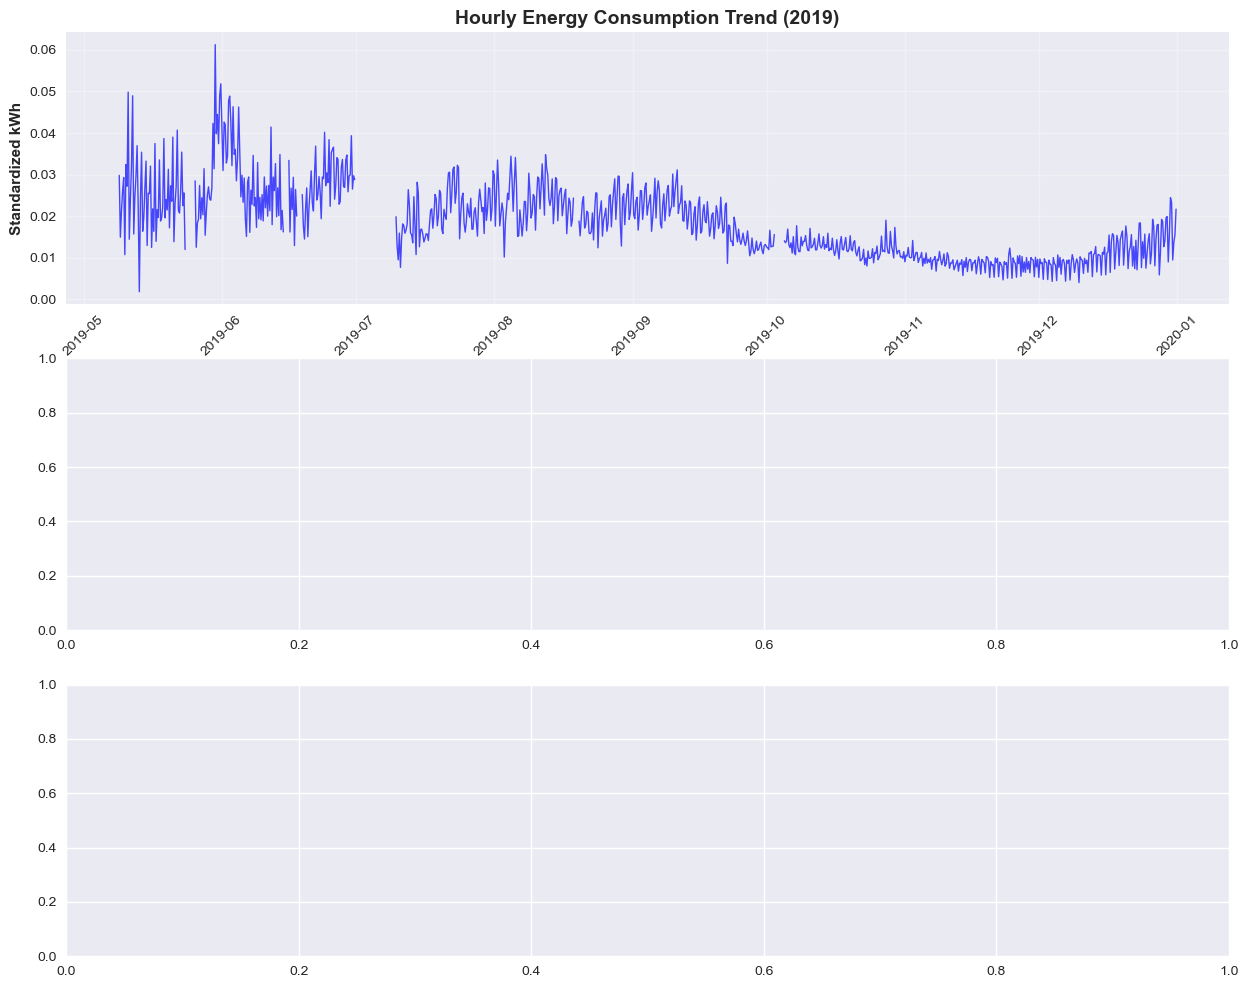

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Set up the plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [15, 10]
plt.rcParams['font.size'] = 12

print("📊 TIME SERIES VISUALIZATION")
print("=" * 50)

# Check if we have a proper datetime index
if not isinstance(df.index, pd.DatetimeIndex):
    print("❌ Index is not datetime. Creating synthetic index...")
    df.index = pd.date_range(start='2019-01-01', periods=len(df), freq='H')
    print(f"✅ Created synthetic index: {df.index.min()} to {df.index.max()}")

# Identify consumption column (assuming 't_kWh' is the main consumption column)
consumption_col = 't_kWh'
print(f"📈 Using '{consumption_col}' as consumption metric")

#  OVERALL TIME SERIES TREND
print("\n1. 📈 Overall Time Series Trend")
print("-" * 30)

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Raw hourly data (sampled for better visualization)
if len(df) > 10000:
    sampled_data = df[consumption_col].resample('6H').mean()  # Sample every 6 hours
else:
    sampled_data = df[consumption_col]

axes[0].plot(sampled_data.index, sampled_data.values, linewidth=1, alpha=0.7, color='blue')
axes[0].set_title('Hourly Energy Consumption Trend (2019)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Standardized kWh', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Daily trend

In [17]:
daily_consumption = df[consumption_col].resample('D').mean()
axes[1].plot(daily_consumption.index, daily_consumption.values, linewidth=2, color='green')
axes[1].set_title('Daily Average Energy Consumption', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Standardized kWh', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Weekly trend

In [18]:
weekly_consumption = df[consumption_col].resample('W').mean()
axes[2].plot(weekly_consumption.index, weekly_consumption.values, linewidth=3, color='red')
axes[2].set_title('Weekly Average Energy Consumption', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Standardized kWh', fontweight='bold')
axes[2].set_xlabel('Date', fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>


2. 🔍 Seasonal Decomposition
------------------------------


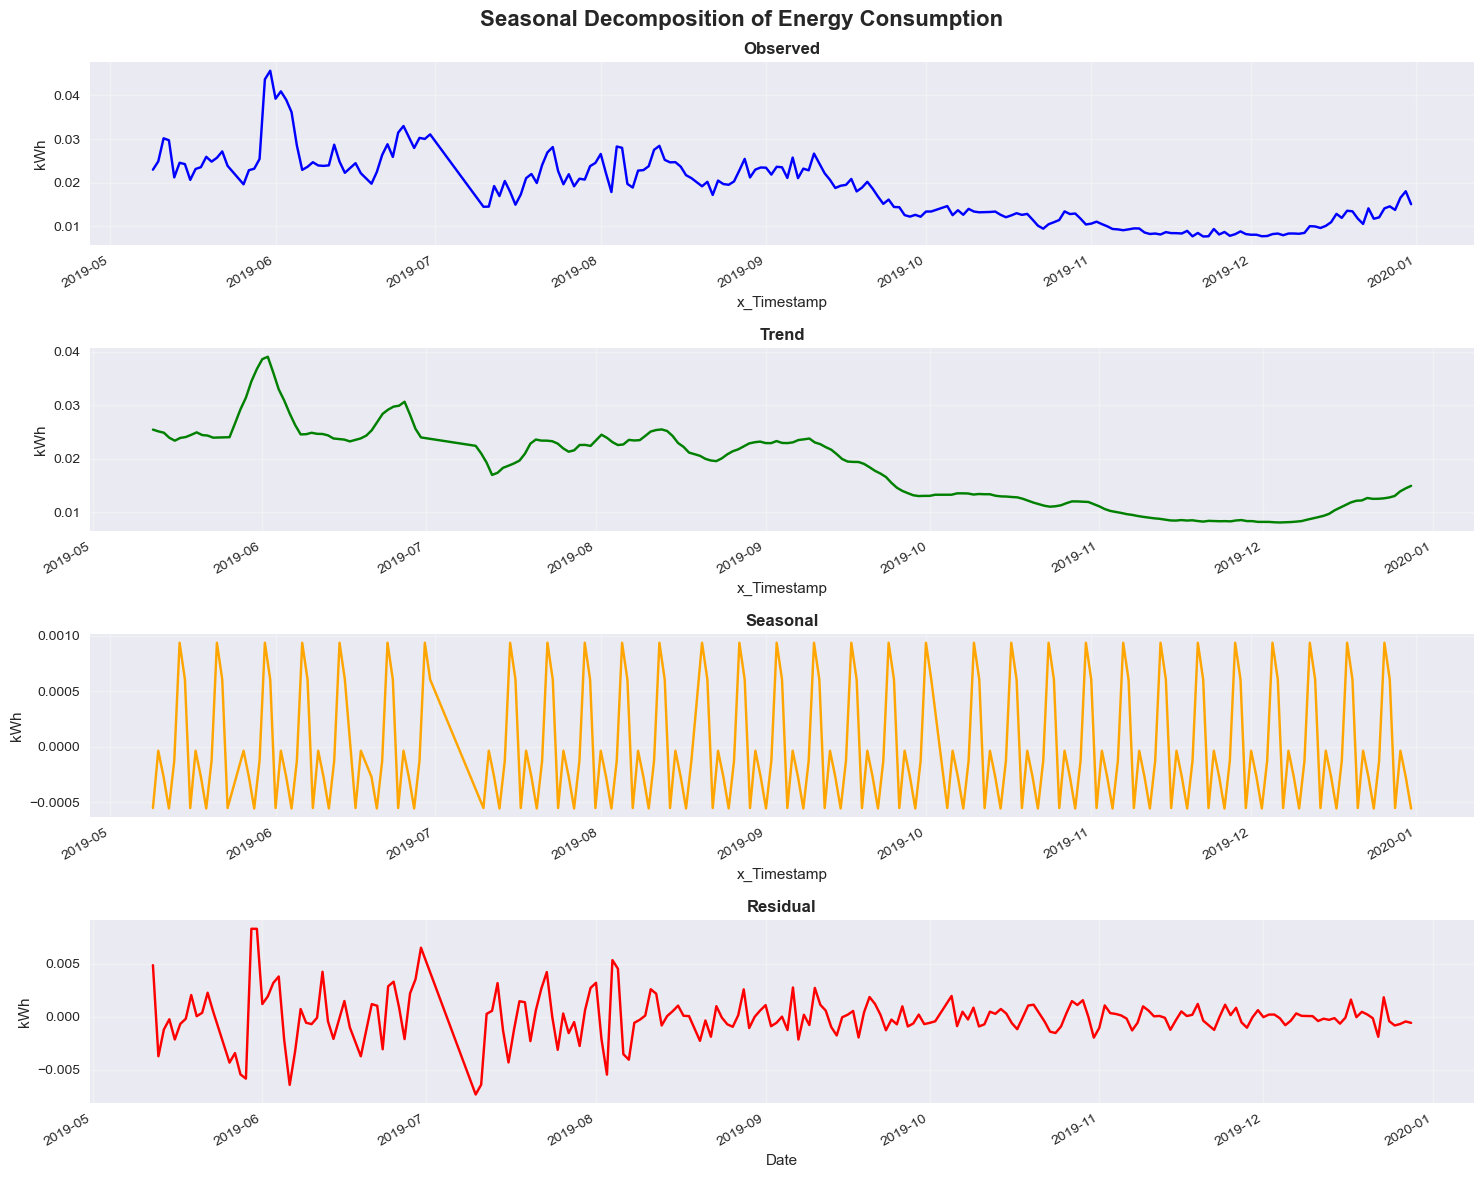

In [19]:
# SEASONAL DECOMPOSITION
print("\n2. 🔍 Seasonal Decomposition")
print("-" * 30)

try:
    # Use daily data for decomposition (better for seasonal patterns)
    if len(daily_consumption) >= 365:
        period = 365  # yearly seasonality
    elif len(daily_consumption) >= 30:
        period = 7    # weekly seasonality
    else:
        period = min(len(daily_consumption) // 2, 2)
    
    decomposition = seasonal_decompose(daily_consumption.dropna(), period=period, model='additive')
    
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    
    decomposition.observed.plot(ax=axes[0], color='blue')
    axes[0].set_title('Observed', fontweight='bold')
    axes[0].set_ylabel('kWh')
    axes[0].grid(True, alpha=0.3)
    
    decomposition.trend.plot(ax=axes[1], color='green')
    axes[1].set_title('Trend', fontweight='bold')
    axes[1].set_ylabel('kWh')
    axes[1].grid(True, alpha=0.3)
    
    decomposition.seasonal.plot(ax=axes[2], color='orange')
    axes[2].set_title('Seasonal', fontweight='bold')
    axes[2].set_ylabel('kWh')
    axes[2].grid(True, alpha=0.3)
    
    decomposition.resid.plot(ax=axes[3], color='red')
    axes[3].set_title('Residual', fontweight='bold')
    axes[3].set_ylabel('kWh')
    axes[3].set_xlabel('Date')
    axes[3].grid(True, alpha=0.3)
    
    plt.suptitle('Seasonal Decomposition of Energy Consumption', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"❌ Seasonal decomposition failed: {e}")

### Diurnal Pattern

✓ File loaded successfully!

PERIOD STATISTICS:
               count  mean   std  min   max  median
period                                             
Daytime       973221  0.01  0.02  0.0  0.29    0.01
Evening Peak  486515  0.02  0.02  0.0  0.23    0.01
Morning Peak  486657  0.01  0.02  0.0  0.24    0.01
Night         972922  0.02  0.02  0.0  0.25    0.01


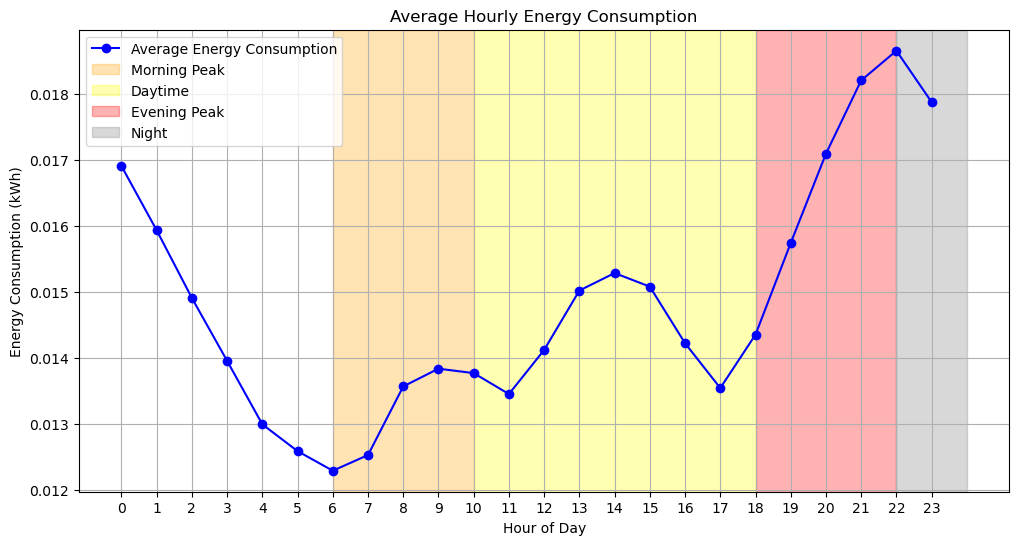

✓ Processed data saved to 'processed_energy_consumption.csv'


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# File path to the energy consumption dataset
file_path = r"E:\mini project msc sem 3\energy consumption dataset\SM Cleaned Data BR2019.csv"

# Load the data
try:
    df = pd.read_csv(file_path)
    print("✓ File loaded successfully!")
except FileNotFoundError:
    print(f"❌ ERROR: File not found at path: {file_path}")
    exit()
except Exception as e:
    print(f"❌ ERROR loading file: {str(e)}")
    exit()

# Identify timestamp and value columns
timestamp_col = None
value_col = None

# Find timestamp and value columns
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['time', 'date', 'datetime', 'timestamp']):
        timestamp_col = col
    if any(keyword in col.lower() for keyword in ['energy', 'consumption', 'power', 'kwh', 'load', 'value']):
        value_col = col

if timestamp_col is None or value_col is None:
    print("⚠ Could not auto-detect columns. Please specify manually.")
    exit()

# Rename columns for consistency
df = df.rename(columns={timestamp_col: 'timestamp', value_col: 'value'})

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Convert value to numeric, remove any non-numeric values
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Remove rows with missing values
df = df.dropna(subset=['timestamp', 'value'])

# Extract hour and classify periods
df['hour'] = df['timestamp'].dt.hour

def classify_period(hour):
    if 6 <= hour < 10:
        return 'Morning Peak'
    elif 10 <= hour < 18:
        return 'Daytime'
    elif 18 <= hour < 22:
        return 'Evening Peak'
    else:
        return 'Night'

df['period'] = df['hour'].apply(classify_period)

# Calculate statistics for each period
period_stats = df.groupby('period')['value'].agg(['count', 'mean', 'std', 'min', 'max', 'median']).round(2)

# Print the statistics
print("\nPERIOD STATISTICS:")
print(period_stats)

# Plotting the average hourly pattern
hourly_avg = df.groupby('hour')['value'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(hourly_avg['hour'], hourly_avg['value'], marker='o', color='blue', label='Average Energy Consumption')
plt.axvspan(6, 10, color='orange', alpha=0.3, label='Morning Peak')
plt.axvspan(10, 18, color='yellow', alpha=0.3, label='Daytime')
plt.axvspan(18, 22, color='red', alpha=0.3, label='Evening Peak')
plt.axvspan(22, 24, color='gray', alpha=0.3, label='Night')

plt.title('Average Hourly Energy Consumption')
plt.xlabel('Hour of Day')
plt.ylabel('Energy Consumption (kWh)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid()
plt.show()

# Save the processed data
df.to_csv('processed_energy_consumption.csv', index=False)
print("✓ Processed data saved to 'processed_energy_consumption.csv'")


### average hourly consumption weekday vs weekend

✓ File loaded successfully!


<Figure size 1200x600 with 0 Axes>

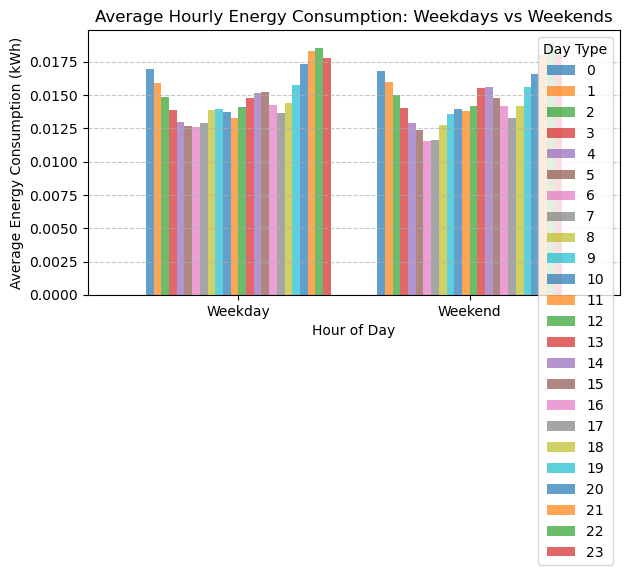

✓ Processed data saved to 'processed_weekly_consumption.csv'


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File path to the energy consumption dataset
file_path = r"E:\mini project msc sem 3\energy consumption dataset\SM Cleaned Data BR2019.csv"

# Load the data
try:
    df = pd.read_csv(file_path)
    print("✓ File loaded successfully!")
except FileNotFoundError:
    print(f"❌ ERROR: File not found at path: {file_path}")
    exit()
except Exception as e:
    print(f"❌ ERROR loading file: {str(e)}")
    exit()

# Identify timestamp and value columns
timestamp_col = None
value_col = None

# Find timestamp and value columns
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['time', 'date', 'datetime', 'timestamp']):
        timestamp_col = col
    if any(keyword in col.lower() for keyword in ['energy', 'consumption', 'power', 'kwh', 'load', 'value']):
        value_col = col

if timestamp_col is None or value_col is None:
    print("⚠ Could not auto-detect columns. Please specify manually.")
    exit()

# Rename columns for consistency
df = df.rename(columns={timestamp_col: 'timestamp', value_col: 'value'})

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Convert value to numeric, remove any non-numeric values
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Remove rows with missing values
df = df.dropna(subset=['timestamp', 'value'])

# Extract day of the week and hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['hour'] = df['timestamp'].dt.hour

# Classify days into Weekdays and Weekends
df['day_type'] = np.where(df['day_of_week'].isin(['Saturday', 'Sunday']), 'Weekend', 'Weekday')

# Group by day type and hour to calculate average consumption
weekly_consumption = df.groupby(['day_type', 'hour'])['value'].mean().unstack()

# Plotting the weekly consumption patterns
plt.figure(figsize=(12, 6))
weekly_consumption.plot(kind='bar', width=0.8, alpha=0.7)
plt.title('Average Hourly Energy Consumption: Weekdays vs Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (kWh)')
plt.xticks(rotation=0)
plt.legend(title='Day Type', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Save the processed data
df.to_csv('processed_weekly_consumption.csv', index=False)
print("✓ Processed data saved to 'processed_weekly_consumption.csv'")


### Monthly and Seasonal Energy Consumption 

In [3]:
import pandas as pd

file_path = r"E:\mini project msc sem 3\energy consumption dataset\SM Cleaned Data BR2019.csv"
df = pd.read_csv(file_path)

print("\n📋 Column Names in Dataset:\n", df.columns.tolist())
print("\n🧾 Sample Rows:\n", df.head())



📋 Column Names in Dataset:
 ['x_Timestamp', 't_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)', 'meter']

🧾 Sample Rows:
            x_Timestamp  t_kWh  z_Avg Voltage (Volt)  z_Avg Current (Amp)  \
0  2019-07-10 00:00:00  0.021                243.10                 1.79   
1  2019-07-10 00:03:00  0.021                242.91                 1.80   
2  2019-07-10 00:06:00  0.021                242.46                 1.83   
3  2019-07-10 00:09:00  0.020                241.27                 1.79   
4  2019-07-10 00:12:00  0.020                240.77                 1.79   

   y_Freq (Hz) meter  
0        50.02  BR02  
1        50.07  BR02  
2        50.00  BR02  
3        49.95  BR02  
4        49.98  BR02  


In [4]:
import re

# Try to detect datetime and energy columns automatically
datetime_col = next((col for col in df.columns if re.search(r'date|time', col, re.IGNORECASE)), None)
energy_col = next((col for col in df.columns if re.search(r'consum|energy|kwh|usage|load', col, re.IGNORECASE)), None)

print("Detected datetime column:", datetime_col)
print("Detected energy column:", energy_col)


Detected datetime column: x_Timestamp
Detected energy column: t_kWh


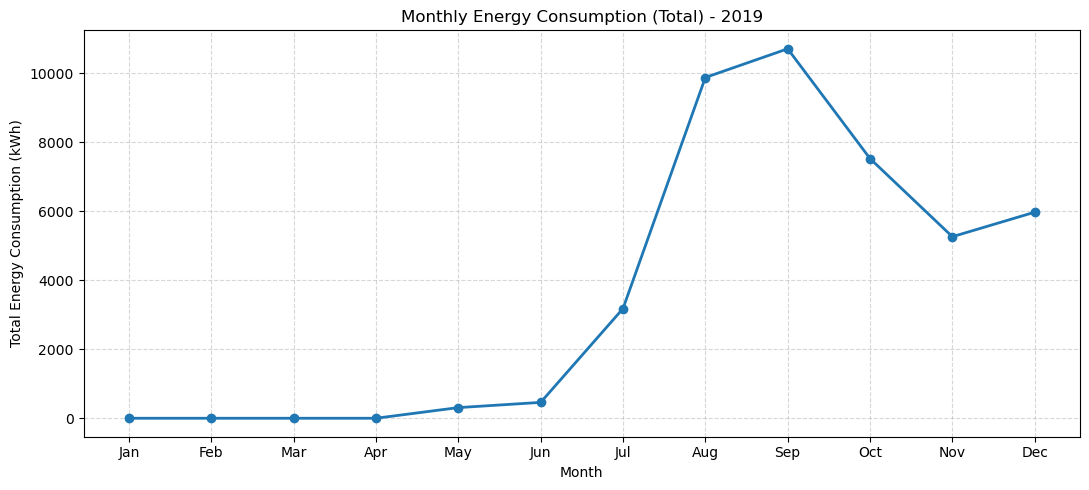

Saved monthly plot to: C:\Users\Shyam\Mini project sem 3\energy_plots\monthly_total.png
\nChecklist & next recommended steps:
1) Verify monthly peaks correspond to expected seasons (cooling/heating).
2) Add temperature/humidity columns to compute correlation with t_kWh.
3) Define exact holiday windows from your calendar and compare holiday vs baseline.
4) Break down consumption by meter/household if available for behavioral insights.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import os

# --- Set your path here ---
file_path = r"E:\mini project msc sem 3\energy consumption dataset\SM Cleaned Data BR2019.csv"

# --- Load & clean ---
df = pd.read_csv(file_path)

# parse timestamp and energy columns (your columns: x_Timestamp, t_kWh)
df['x_Timestamp'] = pd.to_datetime(df['x_Timestamp'], errors='coerce')
df['t_kWh'] = pd.to_numeric(df['t_kWh'], errors='coerce')

# drop rows with missing critical values
df = df.dropna(subset=['x_Timestamp', 't_kWh'])

# temporal features
df['Month'] = df['x_Timestamp'].dt.month
df['DayOfWeek'] = df['x_Timestamp'].dt.day_name()
df['DayType'] = df['DayOfWeek'].apply(lambda x: 'Weekend' if x in ['Saturday','Sunday'] else 'Weekday')

# --- Monthly total aggregated and REINDEX to ensure months 1..12 exist ---
monthly_sum = df.groupby('Month')['t_kWh'].sum().reindex(range(1,13), fill_value=0).reset_index()

# Plot Monthly totals (line)
plt.figure(figsize=(11,5))
plt.plot(monthly_sum['Month'], monthly_sum['t_kWh'], marker='o', linewidth=2)
# Important: ticks positions are 1..12 and labels length is 12 -> no mismatch
plt.xticks(ticks=list(range(1,13)), labels=[calendar.month_abbr[m] for m in range(1,13)])
plt.xlabel('Month')
plt.ylabel('Total Energy Consumption (kWh)')
plt.title('Monthly Energy Consumption (Total) - 2019')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Seasonal average (simple mapping) ---
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Monsoon'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)
seasonal_avg = df.groupby('Season')['t_kWh'].mean().reindex(['Winter','Summer','Monsoon','Autumn']).reset_index()

# --- Save monthly figure (optional) ---
out_dir = os.path.join(os.getcwd(), 'energy_plots')
os.makedirs(out_dir, exist_ok=True)
monthly_path = os.path.join(out_dir, 'monthly_total.png')
plt.figure(figsize=(11,5))
plt.plot(monthly_sum['Month'], monthly_sum['t_kWh'], marker='o', linewidth=2)
plt.xticks(ticks=list(range(1,13)), labels=[calendar.month_abbr[m] for m in range(1,13)])
plt.xlabel('Month')
plt.ylabel('Total Energy Consumption (kWh)')
plt.title('Monthly Energy Consumption (Total) - 2019')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(monthly_path, dpi=150)
plt.close()
print("Saved monthly plot to:", monthly_path)

# --- Short checklist / next steps to do ---
print("\\nChecklist & next recommended steps:")
print("1) Verify monthly peaks correspond to expected seasons (cooling/heating).")
print("2) Add temperature/humidity columns to compute correlation with t_kWh.")
print("3) Define exact holiday windows from your calendar and compare holiday vs baseline.")
print("4) Break down consumption by meter/household if available for behavioral insights.")


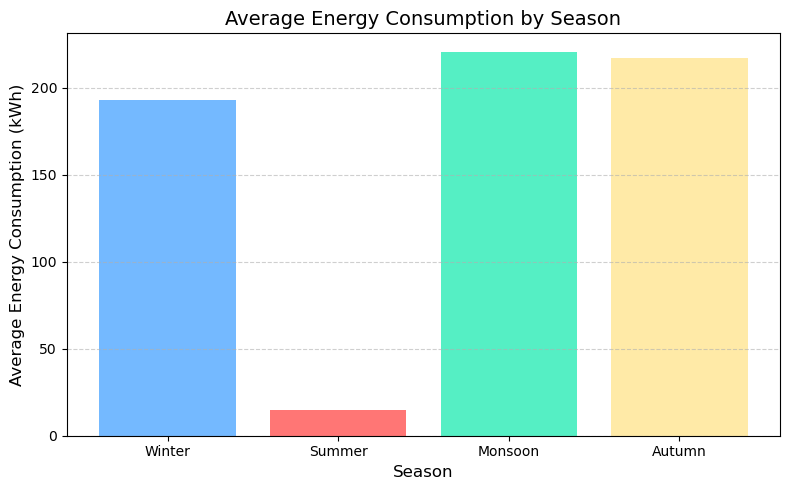

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = r"E:\mini project msc sem 3\energy consumption dataset\SM Cleaned Data BR2019.csv"
df = pd.read_csv(file_path)

# Convert timestamp and clean
df['x_Timestamp'] = pd.to_datetime(df['x_Timestamp'], errors='coerce')
df = df.dropna(subset=['x_Timestamp', 't_kWh'])

# Extract month and compute daily mean
df['Month'] = df['x_Timestamp'].dt.month
df['Date'] = df['x_Timestamp'].dt.date

# Daily total energy
daily_energy = df.groupby('Date')['t_kWh'].sum().reset_index()
daily_energy['Month'] = pd.to_datetime(daily_energy['Date']).dt.month

# Define Indian seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Autumn'

daily_energy['Season'] = daily_energy['Month'].apply(get_season)

# Compute average energy per season
seasonal_avg = daily_energy.groupby('Season')['t_kWh'].mean().reindex(['Winter', 'Summer', 'Monsoon', 'Autumn'])

# Plot
plt.figure(figsize=(8,5))
plt.bar(seasonal_avg.index, seasonal_avg.values, color=['#74b9ff','#ff7675','#55efc4','#ffeaa7'])
plt.title("Average Energy Consumption by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Energy Consumption (kWh)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### ACF of energy consumption

C:\Users\Shyam\AppData\Local\Temp\ipykernel_5536\697525040.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df.resample('H', on='x_Timestamp')['t_kWh'].mean().fillna(0)


<Figure size 1200x600 with 0 Axes>

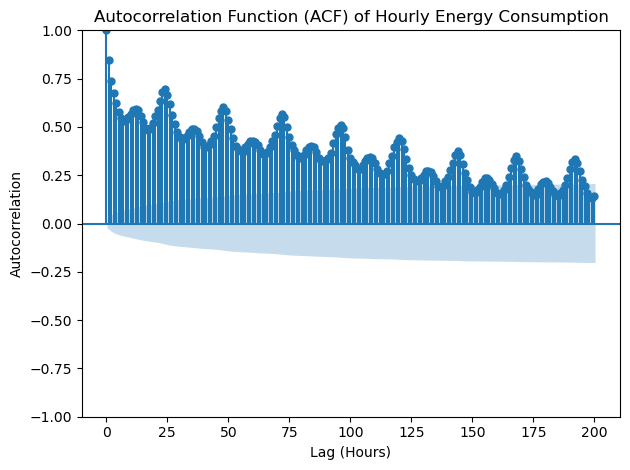

<Figure size 1200x600 with 0 Axes>

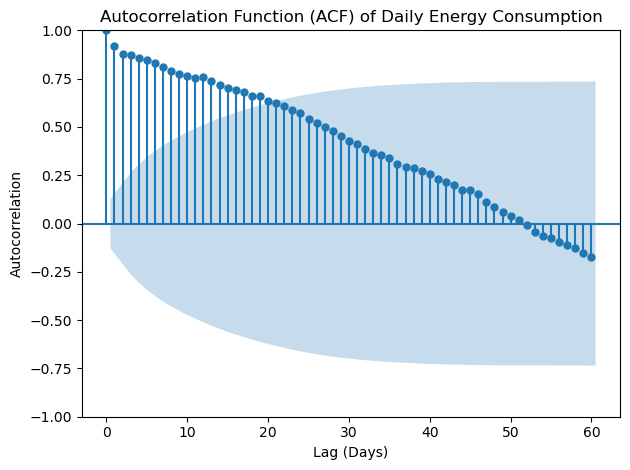

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# ==============================================
# 1️Load and prepare dataset
# ==============================================
file_path = r"E:\mini project msc sem 3\energy consumption dataset\SM Cleaned Data BR2019.csv"
df = pd.read_csv(file_path)

# Convert timestamp and clean
df['x_Timestamp'] = pd.to_datetime(df['x_Timestamp'], errors='coerce')
df = df.dropna(subset=['x_Timestamp', 't_kWh'])

# Sort chronologically
df = df.sort_values('x_Timestamp')

# ==============================================
#  Resample data to hourly or daily frequency
#    (choose based on your dataset granularity)
# ==============================================
# If you have minute-level data:
hourly_df = df.resample('H', on='x_Timestamp')['t_kWh'].mean().fillna(0)

# ==============================================
#  Plot the Autocorrelation Function (ACF)
# ==============================================
plt.figure(figsize=(12,6))
plot_acf(hourly_df, lags=200, alpha=0.05, title="Autocorrelation Function (ACF) of Hourly Energy Consumption")
plt.xlabel("Lag (Hours)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

# ==============================================
# Optional: Daily and Weekly ACF (to see cycles)
# ==============================================
# Daily-level aggregation
daily_df = df.resample('D', on='x_Timestamp')['t_kWh'].sum().fillna(0)

plt.figure(figsize=(12,6))
plot_acf(daily_df, lags=60, alpha=0.05, title="Autocorrelation Function (ACF) of Daily Energy Consumption")
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()


In [ ]:
### 

Loading and preparing electrical parameter data...
Available electrical parameters:
  energy: t_kWh
  current: z_Avg Current (Amp)
  voltage: z_Avg Voltage (Volt)
  frequency: y_Freq (Hz)

Analyzing 2581360 data points with 4 parameters
Parameters: ['t_kWh', 'z_Avg Current (Amp)', 'z_Avg Voltage (Volt)', 'y_Freq (Hz)']

GENERATING ENHANCED CORRELATION MATRIX


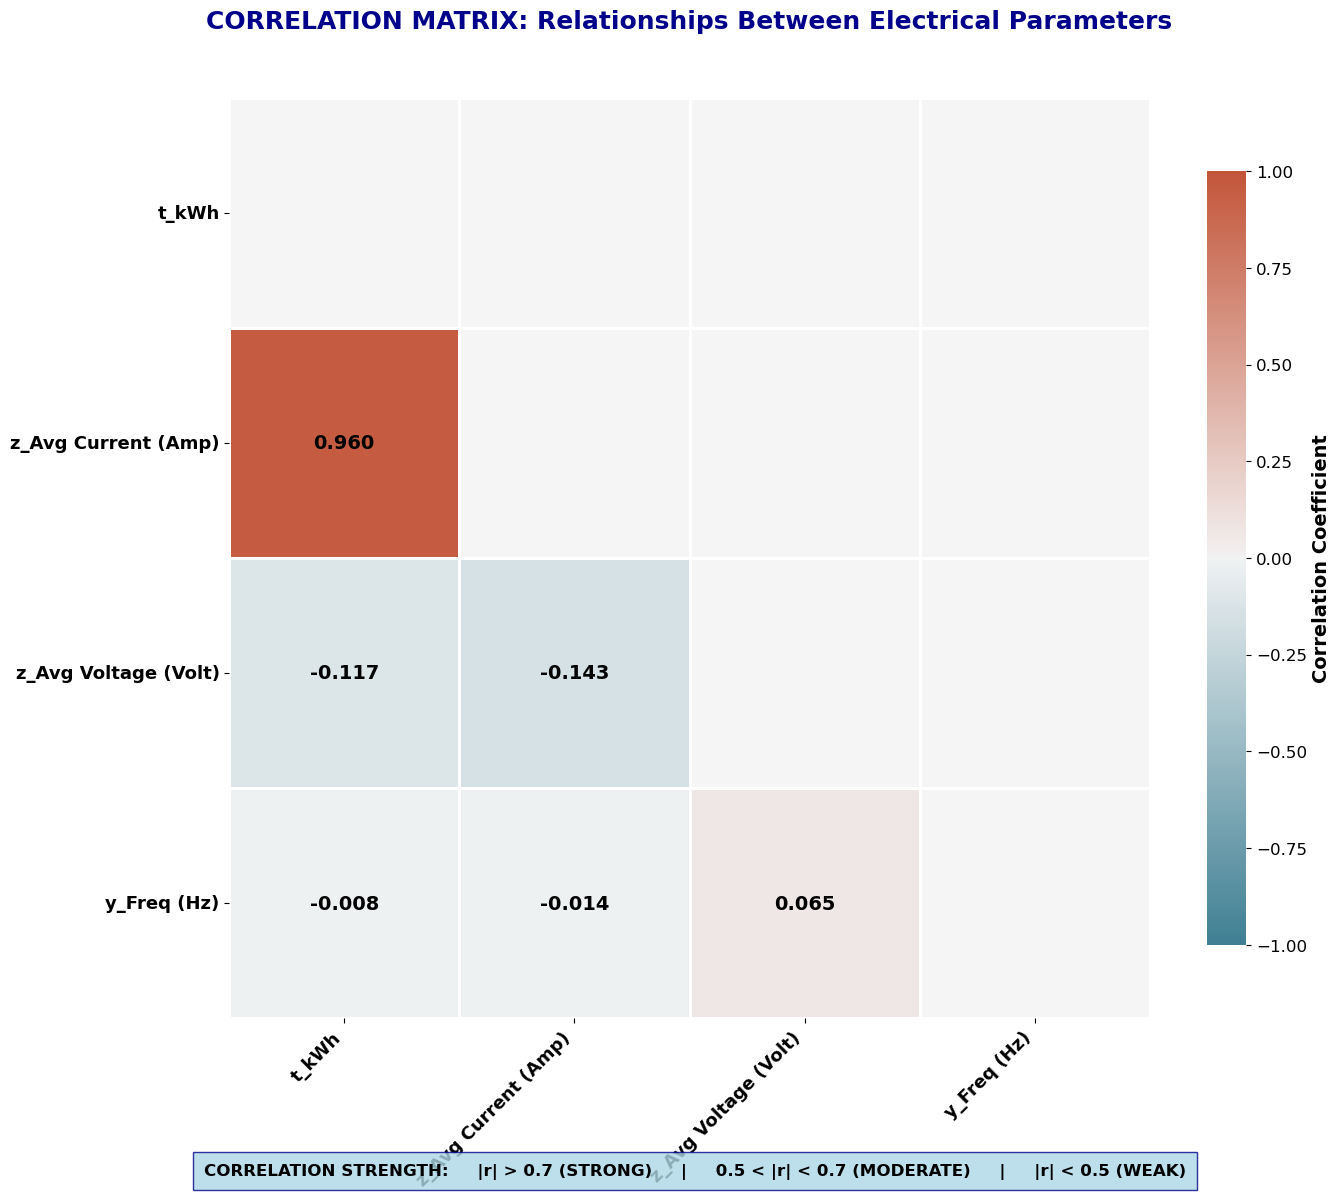


GENERATING ALTERNATIVE CORRELATION MATRIX


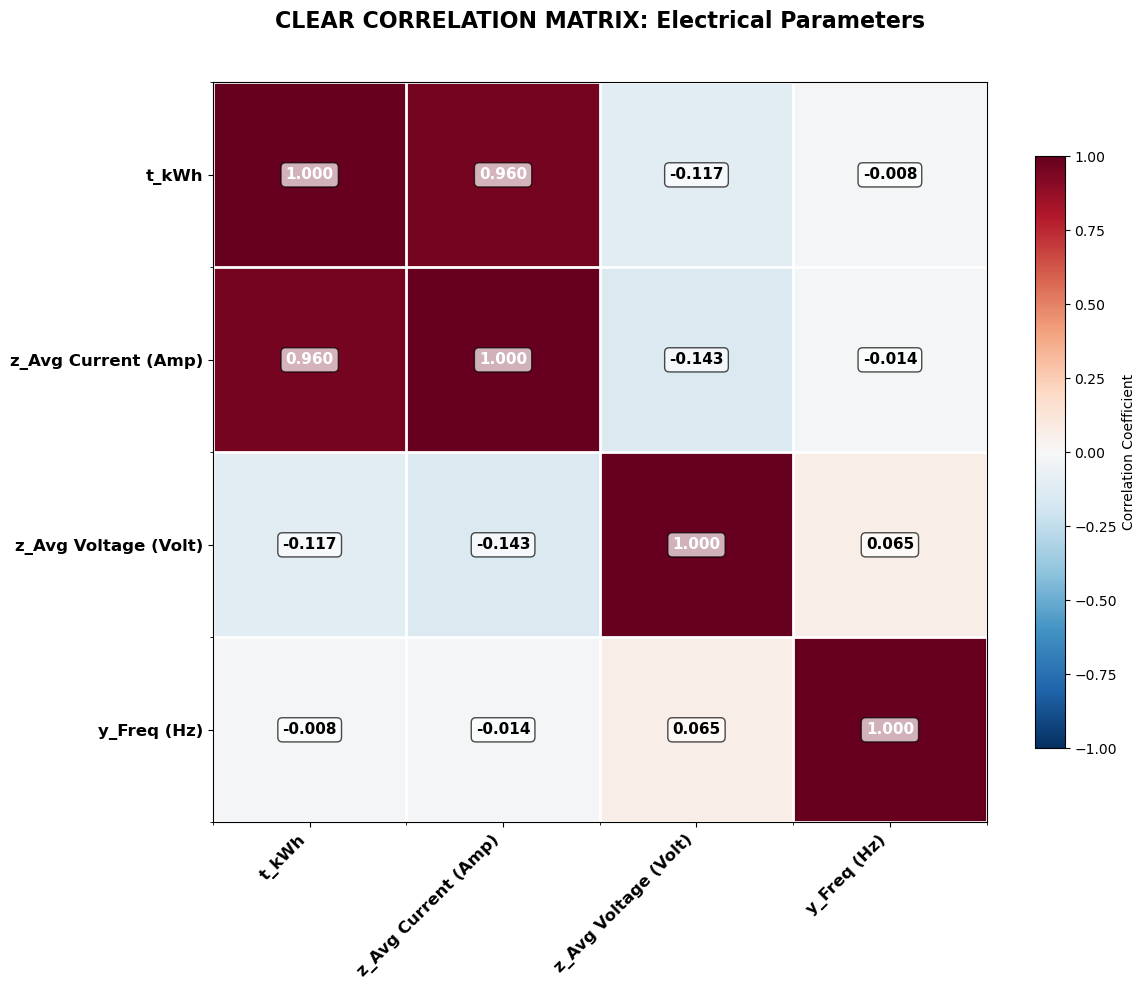


GENERATING SCATTER PLOT MATRIX


<Figure size 1800x1500 with 0 Axes>

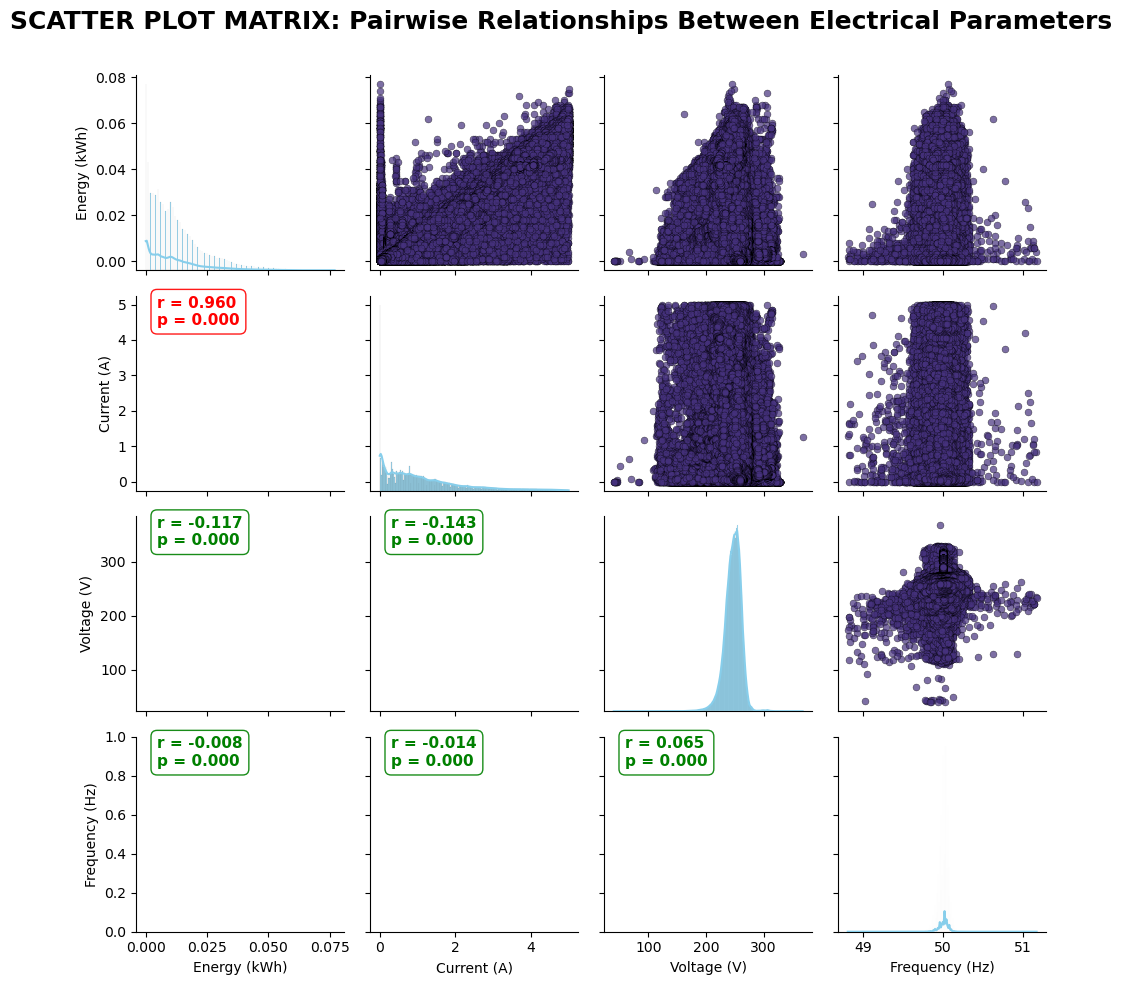

DETAILED CORRELATION ANALYSIS

Correlation Matrix Values:
--------------------------------------------------
                      t_kWh  z_Avg Current (Amp)  z_Avg Voltage (Volt)  \
t_kWh                 1.000                0.960                -0.117   
z_Avg Current (Amp)   0.960                1.000                -0.143   
z_Avg Voltage (Volt) -0.117               -0.143                 1.000   
y_Freq (Hz)          -0.008               -0.014                 0.065   

                      y_Freq (Hz)  
t_kWh                      -0.008  
z_Avg Current (Amp)        -0.014  
z_Avg Voltage (Volt)        0.065  
y_Freq (Hz)                 1.000  

KEY RELATIONSHIP ANALYSIS

Energy-Current Relationship:
  Correlation coefficient: 0.960
  Strength: STRONG POSITIVE correlation
  Significance: ✓ SIGNIFICANT
  ✓ Expected strong positive correlation confirmed
  ✓ Consistent with P = V × I × cos φ relationship

Voltage-Current Relationship:
  Correlation coefficient: -0.143
  Strength: W

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("viridis")

# ==============================================
#  Load and Prepare Dataset
# ==============================================
def load_and_prepare_data(file_path):
    """
    Load the energy consumption dataset and prepare electrical parameters
    """
    # Load dataset
    df = pd.read_csv(file_path)
    
    # Convert timestamp
    df['x_Timestamp'] = pd.to_datetime(df['x_Timestamp'], errors='coerce')
    
    # Assuming your dataset has these columns - adjust based on your actual column names
    expected_columns = {
        'energy': 't_kWh',           # Energy consumption in kWh
        'current': 'I_Amps',         # Current in Amperes
        'voltage': 'V_Volts',        # Voltage in Volts
        'power': 'P_kW',             # Power in kW
        'frequency': 'F_Hz',         # Frequency in Hz
        'power_factor': 'PF'         # Power Factor
    }
    
    # Check which columns actually exist in your dataset
    available_columns = {}
    for param, common_name in expected_columns.items():
        if common_name in df.columns:
            available_columns[param] = common_name
        else:
            # Try to find similar columns
            matching_cols = [col for col in df.columns if param in col.lower() or common_name.split('_')[0] in col]
            if matching_cols:
                available_columns[param] = matching_cols[0]
    
    print("Available electrical parameters:")
    for param, col_name in available_columns.items():
        print(f"  {param}: {col_name}")
    
    # Select only the available electrical parameters
    electrical_params = [available_columns[param] for param in available_columns 
                        if param in ['energy', 'current', 'voltage', 'power', 'frequency', 'power_factor']]
    
    # Create a clean dataframe with electrical parameters
    electrical_df = df[electrical_params].copy()
    
    # Remove any infinite values and outliers
    electrical_df = electrical_df.replace([np.inf, -np.inf], np.nan)
    electrical_df = electrical_df.dropna()
    
    # Remove extreme outliers (beyond 3 standard deviations)
    for column in electrical_df.columns:
        if electrical_df[column].std() > 0:  # Avoid division by zero
            z_scores = np.abs(stats.zscore(electrical_df[column]))
            electrical_df = electrical_df[z_scores < 3]
    
    return electrical_df, available_columns

# ==============================================
# UPDATED: Enhanced Correlation Matrix Visualization
# ==============================================
def plot_correlation_matrix(electrical_df, available_columns):
    """
    Create a CLEAR and HIGHLY VISIBLE correlation matrix heatmap
    """
    # Calculate correlation matrix
    corr_matrix = electrical_df.corr()
    
    # Create figure with larger size for better visibility
    plt.figure(figsize=(14, 12))
    
    # Create custom color map for better contrast
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    
    # Create heatmap with enhanced visibility features
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
    
    # Plot the heatmap with enhanced settings
    ax = sns.heatmap(corr_matrix, 
                     mask=mask,
                     annot=True, 
                     fmt=".3f", 
                     cmap=cmap,
                     center=0,
                     square=True,
                     cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
                     annot_kws={"size": 14, "weight": "bold", "color": "black"},  # Larger, bolder text
                     linewidths=2,  # Thicker lines between cells
                     linecolor='white',  # White lines for better separation
                     vmin=-1, vmax=1)  # Fixed scale from -1 to 1
    
    # Enhanced title and labels
    plt.title('CORRELATION MATRIX: Relationships Between Electrical Parameters\n', 
              fontsize=18, fontweight='bold', pad=30, color='darkblue')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right', fontsize=13, fontweight='bold')
    plt.yticks(rotation=0, fontsize=13, fontweight='bold')
    
    # Add colored background for correlation strength interpretation
    plt.figtext(0.5, 0.02, 
                "CORRELATION STRENGTH:     |r| > 0.7 (STRONG)     |     0.5 < |r| < 0.7 (MODERATE)     |     |r| < 0.5 (WEAK)", 
                ha="center", fontsize=12, fontweight='bold',
                bbox={"facecolor":"lightblue", "alpha":0.8, "pad":8, "edgecolor":"darkblue"})
    
    # Add grid-like appearance
    ax.set_facecolor('whitesmoke')
    
    # Improve color bar visibility
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('Correlation Coefficient', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('correlation_matrix_enhanced.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return corr_matrix

# ==============================================
#  Alternative: Simple Correlation Matrix (Even Clearer)
# ==============================================
def plot_simple_correlation_matrix(electrical_df, available_columns):
    """
    Create a simplified but extremely clear correlation matrix
    """
    corr_matrix = electrical_df.corr()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use a high-contrast colormap
    cmap = plt.cm.RdBu_r
    
    # Plot without masking for maximum clarity
    im = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=12, fontweight='bold')
    ax.set_yticklabels(corr_matrix.columns, fontsize=12, fontweight='bold')
    
    # Add correlation values as text with high contrast
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            # Choose text color based on background
            bg_color = im.norm(corr_matrix.iloc[i, j])
            text_color = 'white' if bg_color > 0.6 else 'black'
            
            ax.text(j, i, f'{corr_matrix.iloc[i, j]:.3f}',
                    ha="center", va="center", 
                    color=text_color, fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))
    
    # Add title and colorbar
    plt.title('CLEAR CORRELATION MATRIX: Electrical Parameters\n', 
              fontsize=16, fontweight='bold', pad=20)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Correlation Coefficient')
    
    # Add grid
    ax.set_xticks(np.arange(-0.5, len(corr_matrix.columns)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(corr_matrix.columns)), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
    
    plt.tight_layout()
    plt.savefig('correlation_matrix_simple.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# ==============================================
# UPDATED: Enhanced Scatter Plot Matrix
# ==============================================
def plot_scatter_matrix(electrical_df, available_columns):
    """
    Create a clear scatter plot matrix
    """
    # Create better column names for display
    display_names = {
        'energy': 'Energy (kWh)',
        'current': 'Current (A)',
        'voltage': 'Voltage (V)',
        'power': 'Power (kW)',
        'frequency': 'Frequency (Hz)',
        'power_factor': 'Power Factor'
    }
    
    # Rename columns for better visualization
    plot_df = electrical_df.copy()
    new_column_names = {}
    for param, col_name in available_columns.items():
        if param in display_names:
            new_column_names[col_name] = display_names[param]
    
    plot_df = plot_df.rename(columns=new_column_names)
    
    # Create scatter plot matrix with enhanced visibility
    fig = plt.figure(figsize=(18, 15))
    
    # Use seaborn's pairplot with enhanced settings
    g = sns.PairGrid(plot_df, diag_sharey=False, height=2.5)
    
    # Enhanced scatter plots on the upper triangle
    g.map_upper(sns.scatterplot, alpha=0.7, s=25, edgecolor='black', linewidth=0.3)
    
    # Enhanced distribution plots on the diagonal
    g.map_diag(sns.histplot, kde=True, alpha=0.8, color='skyblue', edgecolor='black')
    
    # Enhanced correlation coefficients on the lower triangle
    def corrfunc(x, y, **kws):
        r, p = stats.pearsonr(x, y)
        ax = plt.gca()
        # Color code based on correlation strength
        color = 'red' if abs(r) > 0.7 else 'orange' if abs(r) > 0.5 else 'green'
        ax.annotate(f'r = {r:.3f}\np = {p:.3f}', 
                   xy=(0.1, 0.85), xycoords=ax.transAxes,
                   fontsize=11, fontweight='bold', color=color,
                   bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor=color))
    
    g.map_lower(corrfunc)
    
    # Add main title
    plt.suptitle('SCATTER PLOT MATRIX: Pairwise Relationships Between Electrical Parameters\n', 
                 fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.savefig('scatter_plot_matrix_enhanced.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================
#  Detailed Correlation Analysis
# ==============================================
def detailed_correlation_analysis(corr_matrix, available_columns):
    """
    Perform detailed analysis of correlation patterns
    """
    print("="*70)
    print("DETAILED CORRELATION ANALYSIS")
    print("="*70)
    
    # Display correlation matrix in tabular form
    print("\nCorrelation Matrix Values:")
    print("-" * 50)
    print(corr_matrix.round(3))
    
    # Analyze specific relationships
    print("\n" + "="*60)
    print("KEY RELATIONSHIP ANALYSIS")
    print("="*60)
    
    relationships_to_check = [
        ('energy', 'current', 'Energy-Current Relationship'),
        ('voltage', 'current', 'Voltage-Current Relationship'),
        ('energy', 'power', 'Energy-Power Relationship'),
        ('frequency', 'power', 'Frequency-Power Relationship'),
        ('voltage', 'power', 'Voltage-Power Relationship')
    ]
    
    for param1, param2, description in relationships_to_check:
        if param1 in available_columns and param2 in available_columns:
            col1 = available_columns[param1]
            col2 = available_columns[param2]
            if col1 in corr_matrix.index and col2 in corr_matrix.columns:
                corr_value = corr_matrix.loc[col1, col2]
                strength = "STRONG" if abs(corr_value) > 0.7 else "MODERATE" if abs(corr_value) > 0.5 else "WEAK"
                direction = "POSITIVE" if corr_value > 0 else "NEGATIVE"
                significance = "✓ SIGNIFICANT" if abs(corr_value) > 0.5 else "× NOT SIGNIFICANT"
                
                print(f"\n{description}:")
                print(f"  Correlation coefficient: {corr_value:.3f}")
                print(f"  Strength: {strength} {direction} correlation")
                print(f"  Significance: {significance}")
                
                # Provide interpretation
                if param1 == 'energy' and param2 == 'current':
                    if corr_value > 0.7:
                        print("  ✓ Expected strong positive correlation confirmed")
                        print("  ✓ Consistent with P = V × I × cos φ relationship")
    
    # Find strongest correlations
    print("\n" + "="*60)
    print("STRONGEST CORRELATIONS (|r| > 0.7)")
    print("="*60)
    
    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                strong_corrs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
    
    if strong_corrs:
        for var1, var2, corr_val in sorted(strong_corrs, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {var1} ↔ {var2}: r = {corr_val:.3f}")
    else:
        print("  No strong correlations found (|r| > 0.7)")

# ==============================================
#  Main Execution
# ==============================================
def main():
    file_path = r"E:\mini project msc sem 3\energy consumption dataset\SM Cleaned Data BR2019.csv"
    
    try:
        # Load and prepare data
        print("Loading and preparing electrical parameter data...")
        electrical_df, available_columns = load_and_prepare_data(file_path)
        
        if len(available_columns) < 2:
            print("Error: Need at least 2 electrical parameters for correlation analysis")
            return
        
        print(f"\nAnalyzing {len(electrical_df)} data points with {len(available_columns)} parameters")
        print(f"Parameters: {list(available_columns.values())}")
        
        # Generate enhanced visualizations
        print("\n" + "="*50)
        print("GENERATING ENHANCED CORRELATION MATRIX")
        print("="*50)
        corr_matrix = plot_correlation_matrix(electrical_df, available_columns)
        
        print("\n" + "="*50)
        print("GENERATING ALTERNATIVE CORRELATION MATRIX")
        print("="*50)
        plot_simple_correlation_matrix(electrical_df, available_columns)
        
        print("\n" + "="*50)
        print("GENERATING SCATTER PLOT MATRIX")
        print("="*50)
        plot_scatter_matrix(electrical_df, available_columns)
        
        # Perform detailed analysis
        detailed_correlation_analysis(corr_matrix, available_columns)
        
        print("\n" + "="*70)
        print("ANALYSIS COMPLETE!")
        print("Generated files:")
        print("  - correlation_matrix_enhanced.png (Main visualization)")
        print("  - correlation_matrix_simple.png (Alternative clear version)")
        print("  - scatter_plot_matrix_enhanced.png")
        print("="*70)
        
    except Exception as e:
        print(f"Error in analysis: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

In [ ]:
# ==============================================
# BASELINE MACHINE LEARNING MODELS FOR FORECASTING
# ==============================================

# --- Import Required Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# --- Load Dataset ---
file_path = r"E:\mini project msc sem 3\energy consumption dataset\SM Cleaned Data BR2019.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

# --- Check for Missing Values ---
print("\nMissing Values in Each Column:\n", df.isnull().sum())

# --- Example Feature Selection ---
# (Adjust based on your actual dataset column names)
# Assuming 't_kWh' is the target variable (energy consumption)
target_col = 't_kWh'

# Select numerical or relevant predictor columns
features = [col for col in df.columns if col not in [target_col, 'Date', 'Timestamp']]

X = df[features]
y = df[target_col]

# --- Handle Missing Values (if any) ---
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# --- Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================
#  LINEAR REGRESSION
# ==============================================
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# ==============================================
# RANDOM FOREST REGRESSOR
# ==============================================
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# ==============================================
#  SUPPORT VECTOR REGRESSOR (SVR)
# ==============================================
svr = SVR(kernel='rbf', C=100, gamma='auto', epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)

# ==============================================
#  XGBOOST REGRESSOR
# ==============================================
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# ==============================================
#  Model Evaluation Function
# ==============================================
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# --- Evaluate All Models ---
results = []
results.append(evaluate_model(y_test, y_pred_lr, 'Linear Regression'))
results.append(evaluate_model(y_test, y_pred_rf, 'Random Forest'))
results.append(evaluate_model(y_test, y_pred_svr, 'Support Vector Regressor'))
results.append(evaluate_model(y_test, y_pred_xgb, 'XGBoost Regressor'))

results_df = pd.DataFrame(results)
print("\nBaseline Model Performance Comparison:\n")
print(results_df)

# --- Visualization of Model Performance ---
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['RMSE'], color='skyblue')
plt.title("RMSE Comparison of Baseline Models", fontsize=13)
plt.ylabel("RMSE")
plt.show()

# --- Actual vs Predicted Plot for Best Model (example: Random Forest) ---
best_model = rf
y_pred_best = y_pred_rf

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label='Actual', linewidth=2)
plt.plot(y_pred_best[:200], label='Predicted (RF)', linestyle='--')
plt.title("Actual vs Predicted Energy Consumption (Sample)", fontsize=13)
plt.xlabel("Time Index")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()


# DISTRIBUTION AND BOX PLOTS


3. 📊 Distribution Analysis
------------------------------


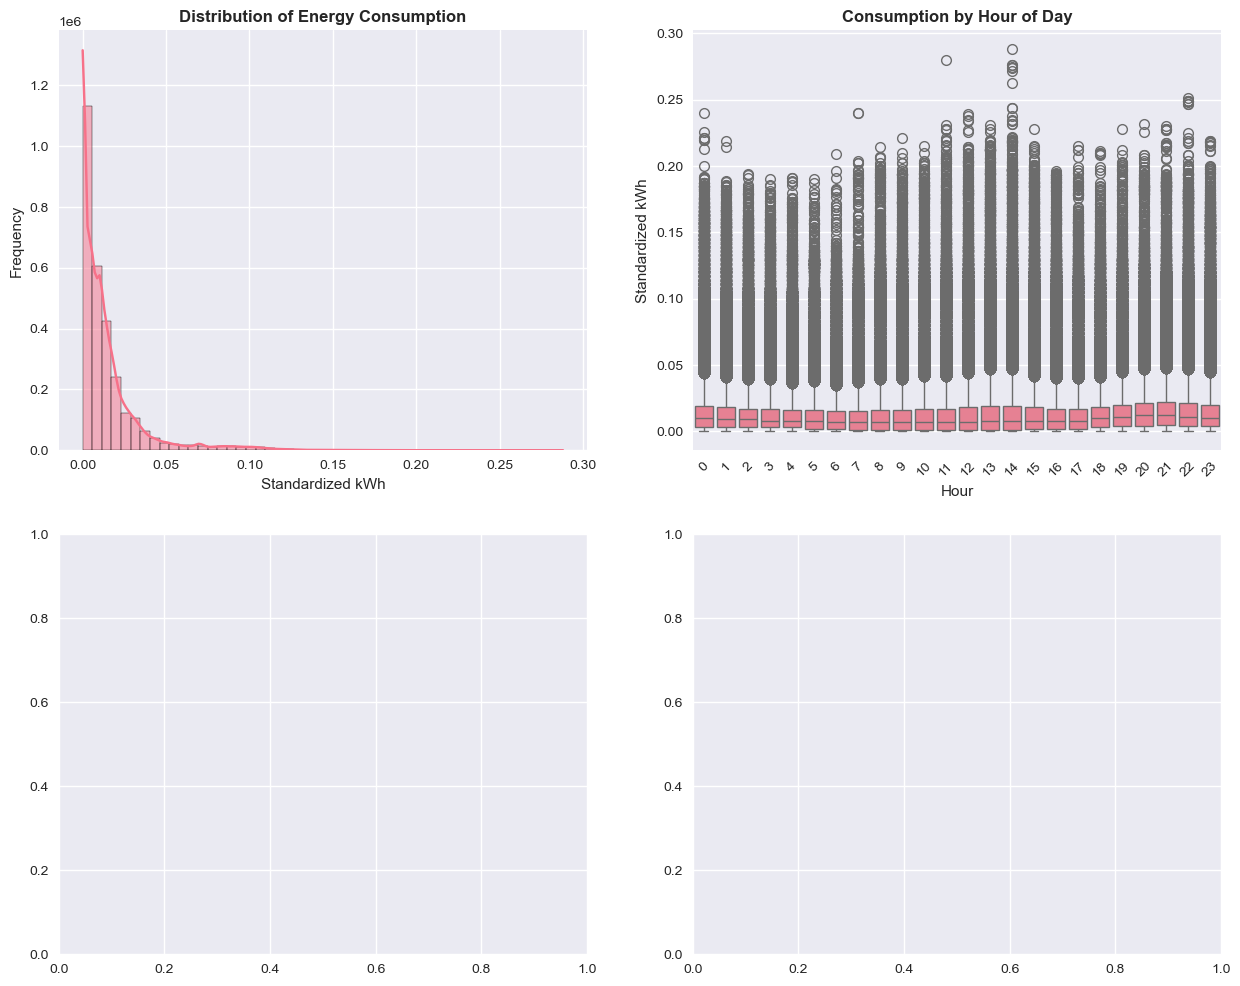

In [30]:
print("\n3. 📊 Distribution Analysis")
print("-" * 30)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distribution plot
sns.histplot(df[consumption_col], kde=True, ax=axes[0, 0], bins=50)
axes[0, 0].set_title('Distribution of Energy Consumption', fontweight='bold')
axes[0, 0].set_xlabel('Standardized kWh')
axes[0, 0].set_ylabel('Frequency')

# Box plot by hour
sns.boxplot(x='hour', y=consumption_col, data=df, ax=axes[0, 1])
axes[0, 1].set_title('Consumption by Hour of Day', fontweight='bold')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Standardized kWh')
axes[0, 1].tick_params(axis='x', rotation=45)

# Box plot by day of week

In [31]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.boxplot(x='day_of_week', y=consumption_col, data=df, ax=axes[1, 0])
axes[1, 0].set_title('Consumption by Day of Week', fontweight='bold')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Standardized kWh')
axes[1, 0].set_xticklabels(day_names)

[Text(0, 0, 'Mon'),
 Text(1, 0, 'Tue'),
 Text(2, 0, 'Wed'),
 Text(3, 0, 'Thu'),
 Text(4, 0, 'Fri'),
 Text(5, 0, 'Sat'),
 Text(6, 0, 'Sun')]

# Box plot by month

In [32]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sns.boxplot(x='month', y=consumption_col, data=df, ax=axes[1, 1])
axes[1, 1].set_title('Consumption by Month', fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Standardized kWh')
axes[1, 1].set_xticklabels(month_names[:len(df['month'].unique())])

plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>


4. 📈 Average Patterns
------------------------------


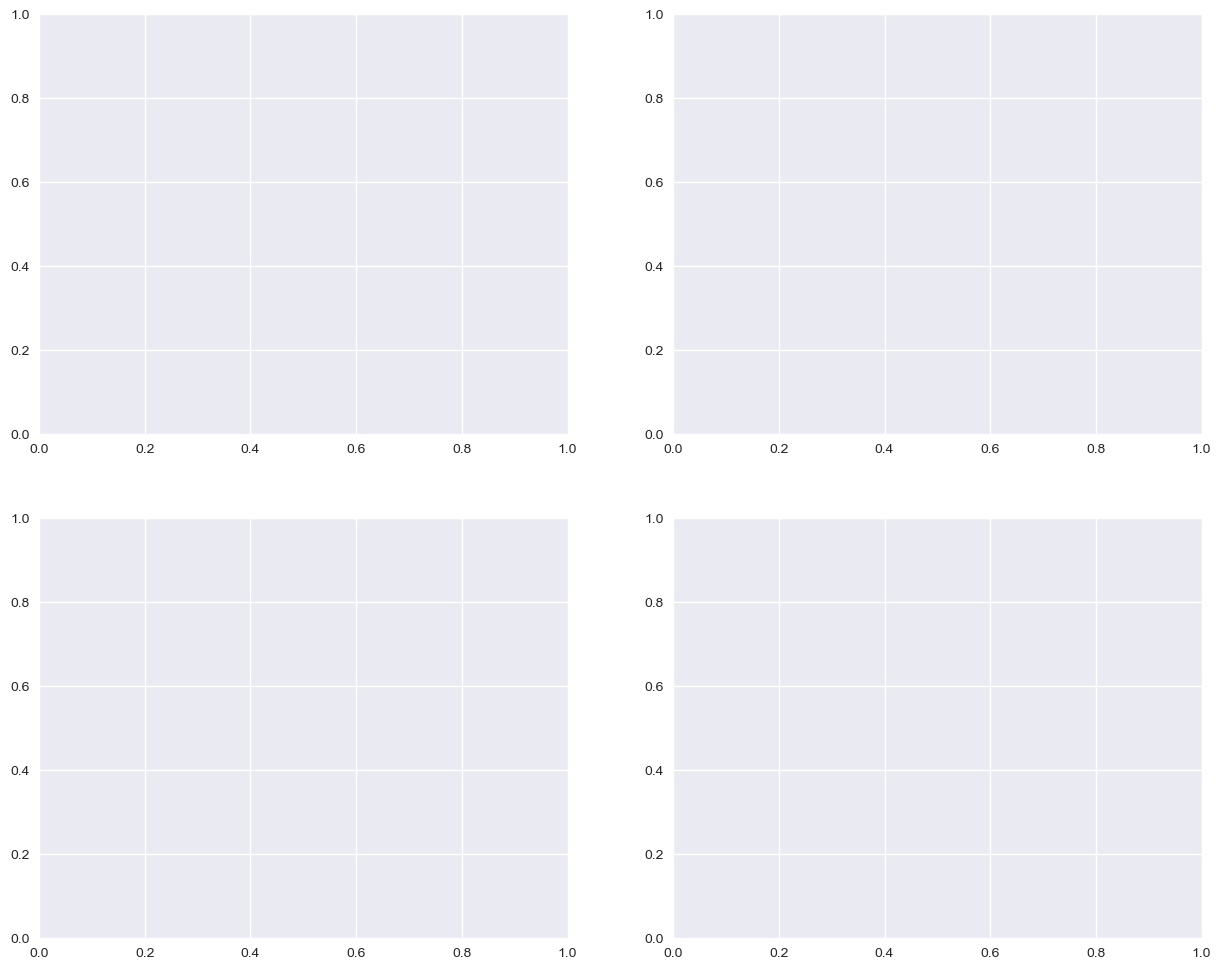

In [25]:
#  AVERAGE PATTERNS
print("\n4. 📈 Average Patterns")
print("-" * 30)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Hourly pattern

In [33]:
axes[0, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, markersize=6)
axes[0, 0].set_title('Average Consumption by Hour', fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Standardized kWh')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

# Daily pattern

In [ ]:
axes[0, 1].plot(day_names, daily_avg.values, marker='o', linewidth=2, markersize=6)
axes[0, 1].set_title('Average Consumption by Day of Week', fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Standardized kWh')
axes[0, 1].grid(True, alpha=0.3)

# Monthly pattern

In [28]:
monthly_avg = df.groupby('month')[consumption_col].mean()
axes[1, 0].plot(month_names[:len(monthly_avg)], monthly_avg.values, marker='o', linewidth=2, markersize=6)
axes[1, 0].set_title('Average Consumption by Month', fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Standardized kWh')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

In [34]:
# Weekend vs Weekday
axes[1, 1].bar(['Weekday', 'Weekend'], weekend_avg.values, color=['skyblue', 'lightcoral'])
axes[1, 1].set_title('Average Consumption: Weekday vs Weekend', fontweight='bold')
axes[1, 1].set_ylabel('Standardized kWh')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

# CORRELATION WITH OTHER VARIABLES


5. 🔗 Correlation Analysis
------------------------------
Other variables available for correlation: ['z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)']


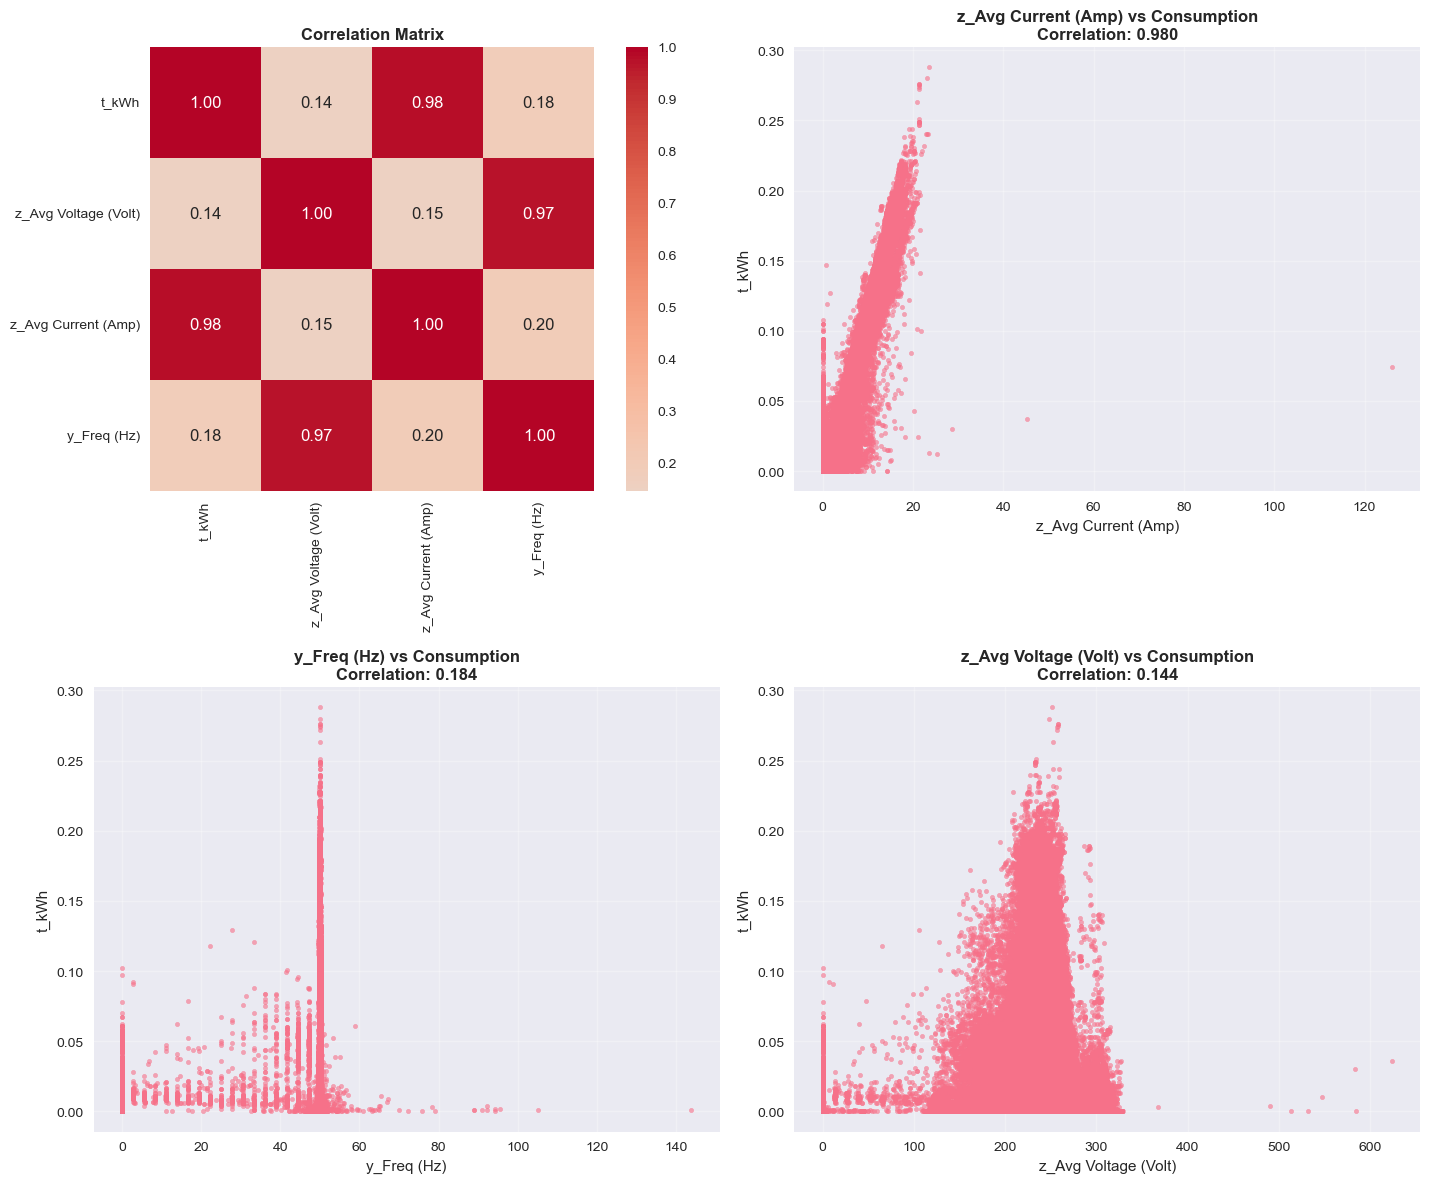

In [35]:
print("\n5. 🔗 Correlation Analysis")
print("-" * 30)

other_vars = [col for col in df.columns if col != consumption_col and col not in ['hour', 'day_of_week', 'month', 'is_weekend'] and df[col].dtype in [np.float64, np.int64]]

if other_vars:
    print(f"Other variables available for correlation: {other_vars}")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Correlation heatmap
    corr_data = df[[consumption_col] + other_vars]
    correlation_matrix = corr_data.corr()
    
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f', ax=axes[0, 0])
    axes[0, 0].set_title('Correlation Matrix', fontweight='bold')
    
    # Scatter plots for top correlations
    top_correlations = correlation_matrix[consumption_col].drop(consumption_col).abs().sort_values(ascending=False)
    
    for i, (var, corr_value) in enumerate(top_correlations.head(3).items()):
        row = (i + 1) // 2
        col = (i + 1) % 2
        axes[row, col].scatter(df[var], df[consumption_col], alpha=0.6, s=10)
        axes[row, col].set_xlabel(var)
        axes[row, col].set_ylabel(consumption_col)
        axes[row, col].set_title(f'{var} vs Consumption\nCorrelation: {corr_value:.3f}', fontweight='bold')
        axes[row, col].grid(True, alpha=0.3)
    
    if len(top_correlations) < 3:
        fig.delaxes(axes[1, 1])
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No other numeric variables found for correlation analysis")

# ANOMALY DETECTION VISUALIZATION


6. 🚨 Anomaly Detection
------------------------------
Detected 86840 statistical anomalies


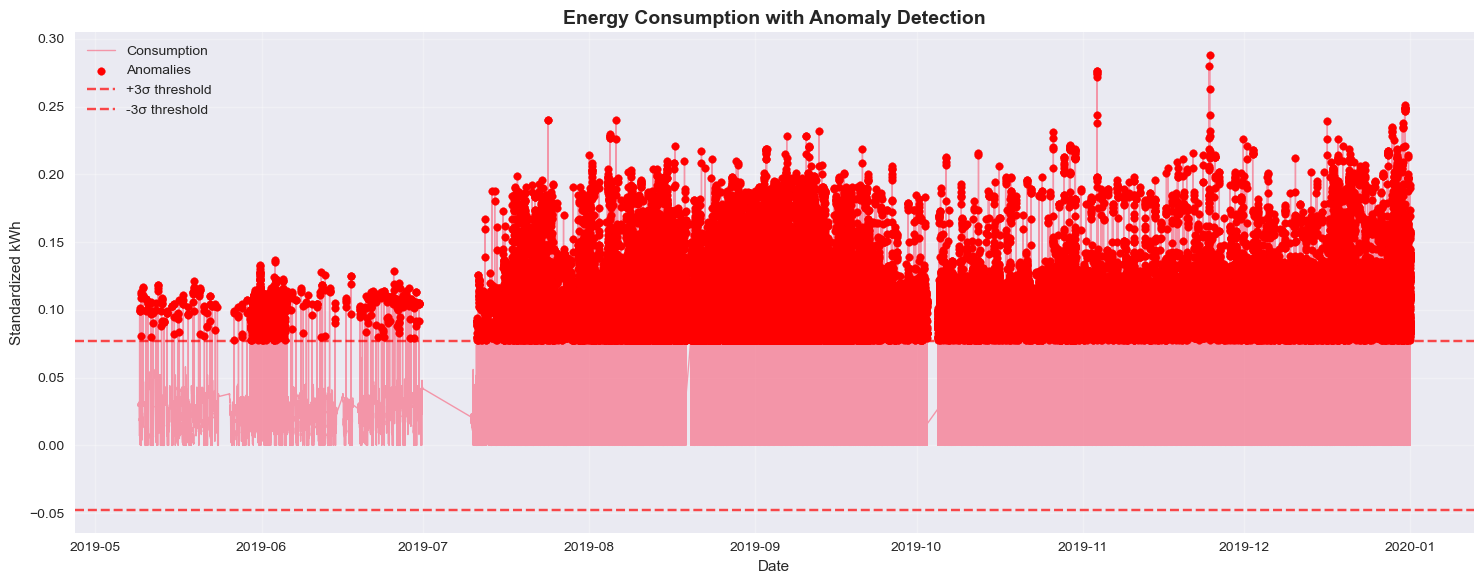

In [36]:
print("\n6. 🚨 Anomaly Detection")
print("-" * 30)

mean_consumption = df[consumption_col].mean()
std_consumption = df[consumption_col].std()

anomalies = df[(df[consumption_col] > mean_consumption + 3*std_consumption) | 
               (df[consumption_col] < mean_consumption - 3*std_consumption)]

print(f"Detected {len(anomalies)} statistical anomalies")

plt.figure(figsize=(15, 6))
plt.plot(df.index, df[consumption_col], alpha=0.7, label='Consumption', linewidth=1)
plt.scatter(anomalies.index, anomalies[consumption_col], color='red', s=30, label='Anomalies', zorder=5)
plt.axhline(y=mean_consumption + 3*std_consumption, color='r', linestyle='--', alpha=0.7, label='+3σ threshold')
plt.axhline(y=mean_consumption - 3*std_consumption, color='r', linestyle='--', alpha=0.7, label='-3σ threshold')
plt.title('Energy Consumption with Anomaly Detection', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Standardized kWh')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. SUMMARY STATISTICS

In [39]:
# --- SUMMARY STATISTICS FIXED ---

# Recalculate averages in case they are not defined
hourly_avg = df.groupby('hour')[consumption_col].mean()
daily_avg = df.groupby('day_of_week')[consumption_col].mean()
weekend_avg = df.groupby('is_weekend')[consumption_col].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print("\n7. 📋 Summary Statistics")
print("-" * 30)

print("📊 Consumption Statistics:")
print(f"   Mean: {df[consumption_col].mean():.4f}")
print(f"   Std: {df[consumption_col].std():.4f}")
print(f"   Min: {df[consumption_col].min():.4f}")
print(f"   Max: {df[consumption_col].max():.4f}")
print(f"   Median: {df[consumption_col].median():.4f}")
print(f"   Total data points: {len(df):,}")

print(f"\n📅 Time Range:")
print(f"   Start: {df.index.min()}")
print(f"   End: {df.index.max()}")
print(f"   Duration: {(df.index.max() - df.index.min()).days} days")

print(f"\n🕒 Time-based Patterns:")
print(f"   Peak hour: {hourly_avg.idxmax()} ({hourly_avg.max():.3f})")
print(f"   Lowest hour: {hourly_avg.idxmin()} ({hourly_avg.min():.3f})")
print(f"   Peak day: {day_names[daily_avg.idxmax()]} ({daily_avg.max():.3f})")
print(f"   Weekend avg: {weekend_avg.loc[1]:.3f}")
print(f"   Weekday avg: {weekend_avg.loc[0]:.3f}")



7. 📋 Summary Statistics
------------------------------
📊 Consumption Statistics:
   Mean: 0.0148
   Std: 0.0208
   Min: 0.0000
   Max: 0.2880
   Median: 0.0090
   Total data points: 2,919,315

📅 Time Range:
   Start: 2019-05-09 00:00:00
   End: 2019-12-31 23:57:00
   Duration: 236 days

🕒 Time-based Patterns:
   Peak hour: 22 (0.019)
   Lowest hour: 6 (0.012)
   Peak day: Fri (0.015)
   Weekend avg: 0.015
   Weekday avg: 0.015


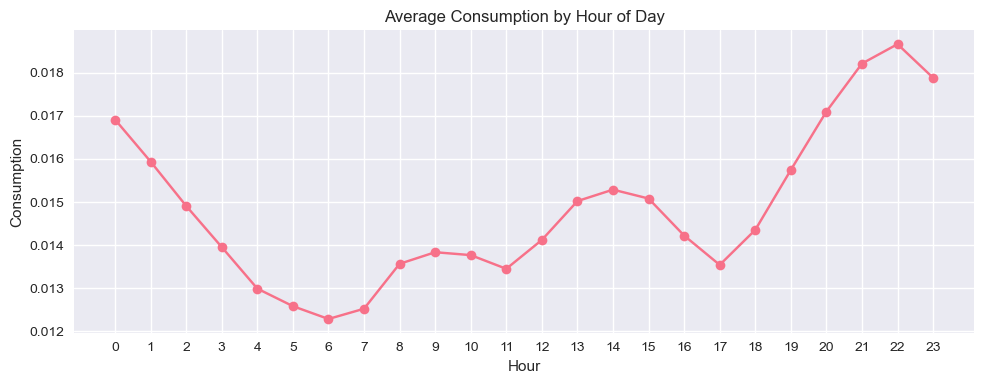

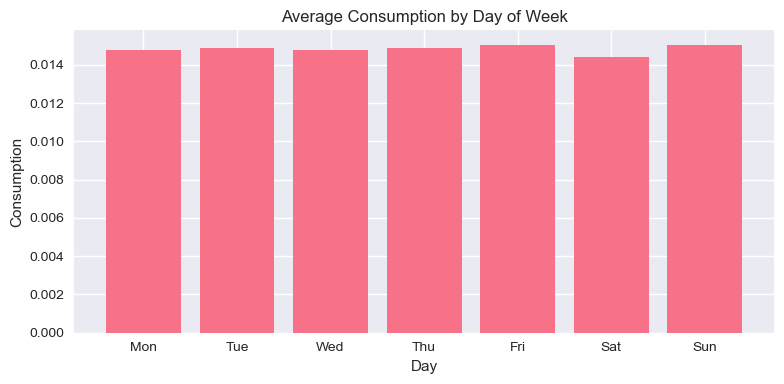

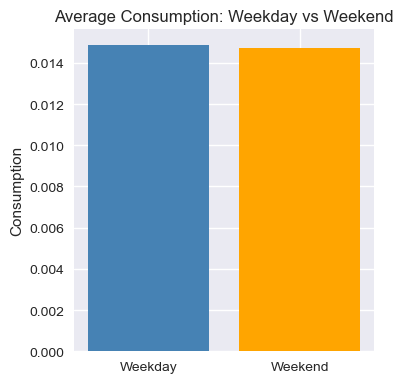

In [40]:
import matplotlib.pyplot as plt

# Recalculate needed variables 
hourly_avg = df.groupby('hour')[consumption_col].mean()
daily_avg = df.groupby('day_of_week')[consumption_col].mean()
weekend_avg = df.groupby('is_weekend')[consumption_col].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# --- Plot 1: Average consumption by hour ---
plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title("Average Consumption by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Consumption")
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# --- Plot 2: Average consumption by day of week ---
plt.figure(figsize=(8, 4))
plt.bar(day_names, daily_avg.values)
plt.title("Average Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Consumption")
plt.tight_layout()
plt.show()

# --- Plot 3: Weekend vs Weekday comparison ---
plt.figure(figsize=(4, 4))
plt.bar(["Weekday", "Weekend"], [weekend_avg.loc[0], weekend_avg.loc[1]], color=['steelblue', 'orange'])
plt.title("Average Consumption: Weekday vs Weekend")
plt.ylabel("Consumption")
plt.tight_layout()
plt.show()


### feature engineering

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
file_path = r"C:\Users\Shyam\Downloads\energy consumption dataset\SM Cleaned Data BR2019.csv"
df = pd.read_csv(file_path)

# Initial Data Check
print("Initial Data Info:")
print(df.info())
print("\nInitial Data Head:")
print(df.head())

Initial Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919315 entries, 0 to 2919314
Data columns (total 6 columns):
 #   Column                Dtype  
---  ------                -----  
 0   x_Timestamp           object 
 1   t_kWh                 float64
 2   z_Avg Voltage (Volt)  float64
 3   z_Avg Current (Amp)   float64
 4   y_Freq (Hz)           float64
 5   meter                 object 
dtypes: float64(4), object(2)
memory usage: 133.6+ MB
None

Initial Data Head:
           x_Timestamp  t_kWh  z_Avg Voltage (Volt)  z_Avg Current (Amp)  \
0  2019-07-10 00:00:00  0.021                243.10                 1.79   
1  2019-07-10 00:03:00  0.021                242.91                 1.80   
2  2019-07-10 00:06:00  0.021                242.46                 1.83   
3  2019-07-10 00:09:00  0.020                241.27                 1.79   
4  2019-07-10 00:12:00  0.020                240.77                 1.79   

   y_Freq (Hz) meter  
0        50.02  BR02  
1      

### Handling datetime 

In [3]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['Hour'] = df['Date'].dt.hour
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    # Weekend flag
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
    # Time-of-day cyclic features
    df['Hour_sin'] = np.sin(2 * np.pi * df['Hour']/24)
    df['Hour_cos'] = np.cos(2 * np.pi * df['Hour']/24)
    # Month cyclic features
    df['Month_sin'] = np.sin(2 * np.pi * df['Month']/12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month']/12)
    print("\nDatetime & Cyclical Features Added")
else:
    print("\nNo 'Date' column found. Skipping datetime features.")

# --- Step 2: Handle missing values ---
print("\nMissing Values Before:\n", df.isnull().sum())
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)
print("\nMissing Values After:\n", df.isnull().sum())


No 'Date' column found. Skipping datetime features.

Missing Values Before:
 x_Timestamp             0
t_kWh                   0
z_Avg Voltage (Volt)    0
z_Avg Current (Amp)     0
y_Freq (Hz)             0
meter                   0
dtype: int64


C:\Users\Shyam\AppData\Local\Temp\ipykernel_27964\2344875520.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Shyam\AppData\Local\Temp\ipykernel_27964\2344875520.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)



Missing Values After:
 x_Timestamp             0
t_kWh                   0
z_Avg Voltage (Volt)    0
z_Avg Current (Amp)     0
y_Freq (Hz)             0
meter                   0
dtype: int64


### Lag & rolling features 

In [5]:
if 'Consumption' in df.columns:
    # Lag features
    df['Consumption_Lag1'] = df['Consumption'].shift(1)
    df['Consumption_Lag24'] = df['Consumption'].shift(24)
    df['Consumption_Lag168'] = df['Consumption'].shift(168)  # Weekly lag
    # Rolling features
    df['Consumption_RollingMean_3'] = df['Consumption'].rolling(window=3).mean()
    df['Consumption_RollingMean_24'] = df['Consumption'].rolling(window=24).mean()
    df['Consumption_RollingMean_168'] = df['Consumption'].rolling(window=168).mean()
    # Rolling std
    df['Consumption_RollingStd_24'] = df['Consumption'].rolling(window=24).std()
    print("\nLag & Rolling Features Added")

### Encoding categorical variables

In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Encoded {col}")

Encoded x_Timestamp
Encoded meter


In [7]:
# - Scaling numerical features ---
numeric_cols = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("\nNumerical Features Scaled")
print("\nFinal Data Head after Advanced Feature Engineering:")
print(df.head())
print("\nFinal Data Info:")
print(df.info())


Numerical Features Scaled

Final Data Head after Advanced Feature Engineering:
   x_Timestamp    t_kWh  z_Avg Voltage (Volt)  z_Avg Current (Amp)  \
0    -2.066879  0.29607              0.206159             0.218154   
1    -2.066833  0.29607              0.203087             0.223554   
2    -2.066787  0.29607              0.195809             0.239753   
3    -2.066741  0.24808              0.176564             0.218154   
4    -2.066696  0.24808              0.168478             0.218154   

   y_Freq (Hz)     meter  
0     0.262700 -1.649539  
1     0.266786 -1.649539  
2     0.261065 -1.649539  
3     0.256979 -1.649539  
4     0.259431 -1.649539  

Final Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919315 entries, 0 to 2919314
Data columns (total 6 columns):
 #   Column                Dtype  
---  ------                -----  
 0   x_Timestamp           float64
 1   t_kWh                 float64
 2   z_Avg Voltage (Volt)  float64
 3   z_Avg Current (Amp)   float

### train test split and validation strategy

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Load dataset ---
file_path = r"C:\Users\Shyam\Downloads\energy consumption dataset\SM Cleaned Data BR2019.csv"
df = pd.read_csv(file_path)give 

# --- Detect datetime column ---
possible_date_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
if len(possible_date_cols) > 0:
    df.rename(columns={possible_date_cols[0]: 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
else:
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

# --- Define the correct target column ---
target_col = 't_kWh'  # <-- updated here

# --- Train-Test Split ---
train_size = 0.8
split_index = int(len(df) * train_size)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")

# --- Separate features and target ---
X_train = train_df.drop(columns=['Date', target_col], errors='ignore')
y_train = train_df[target_col]
X_test = test_df.drop(columns=['Date', target_col], errors='ignore')
y_test = test_df[target_col]

# --- Encode categorical columns ---
categorical_cols = X_train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# --- Scale numeric columns ---
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

print("\nFeature columns after encoding and scaling:")
print(numeric_cols.tolist())

# --- Time Series Cross-Validation ---
tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_index, val_index) in enumerate(tscv.split(X_train_scaled)):
    print(f"Fold {fold+1}: Train {len(train_index)} | Validation {len(val_index)}")


Train size: 2335452 | Test size: 583863

Feature columns after encoding and scaling:
['z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)', 'meter']
Fold 1: Train 389242 | Validation 389242
Fold 2: Train 778484 | Validation 389242
Fold 3: Train 1167726 | Validation 389242
Fold 4: Train 1556968 | Validation 389242
Fold 5: Train 1946210 | Validation 389242


## baseline model

Loading dataset in chunks...
Error inspecting file: 'DataFrame' object does not support the context manager protocol
Error loading data: name 'columns_to_keep' is not defined
No data loaded. Exiting.
Dataset too large. Sampling 50,000 rows for baseline modeling...
Sampled dataset shape: (50000, 5)

=== Handling Missing Values ===
Series([], dtype: int64)

Features shape: (50000, 4)
Target shape: (50000,)
Categorical columns: ['meter']
Column 'meter' has 46 unique values
Final features shape: (50000, 4)

Training set shape: (40000, 4)
Testing set shape: (10000, 4)

BASELINE MODEL 1: RIDGE REGRESSION
Mean Absolute Error (MAE): 0.0020
Root Mean Squared Error (RMSE): 0.0037
R-squared (R²): 0.9675

BASELINE MODEL 2: RANDOM FOREST (Simplified)
Mean Absolute Error (MAE): 0.0019
Root Mean Squared Error (RMSE): 0.0034
R-squared (R²): 0.9726

FINAL MODEL COMPARISON
Metric               Baseline (Mean) Ridge Regression   Random Forest  
MAE                  0.0130          0.0020             0.00

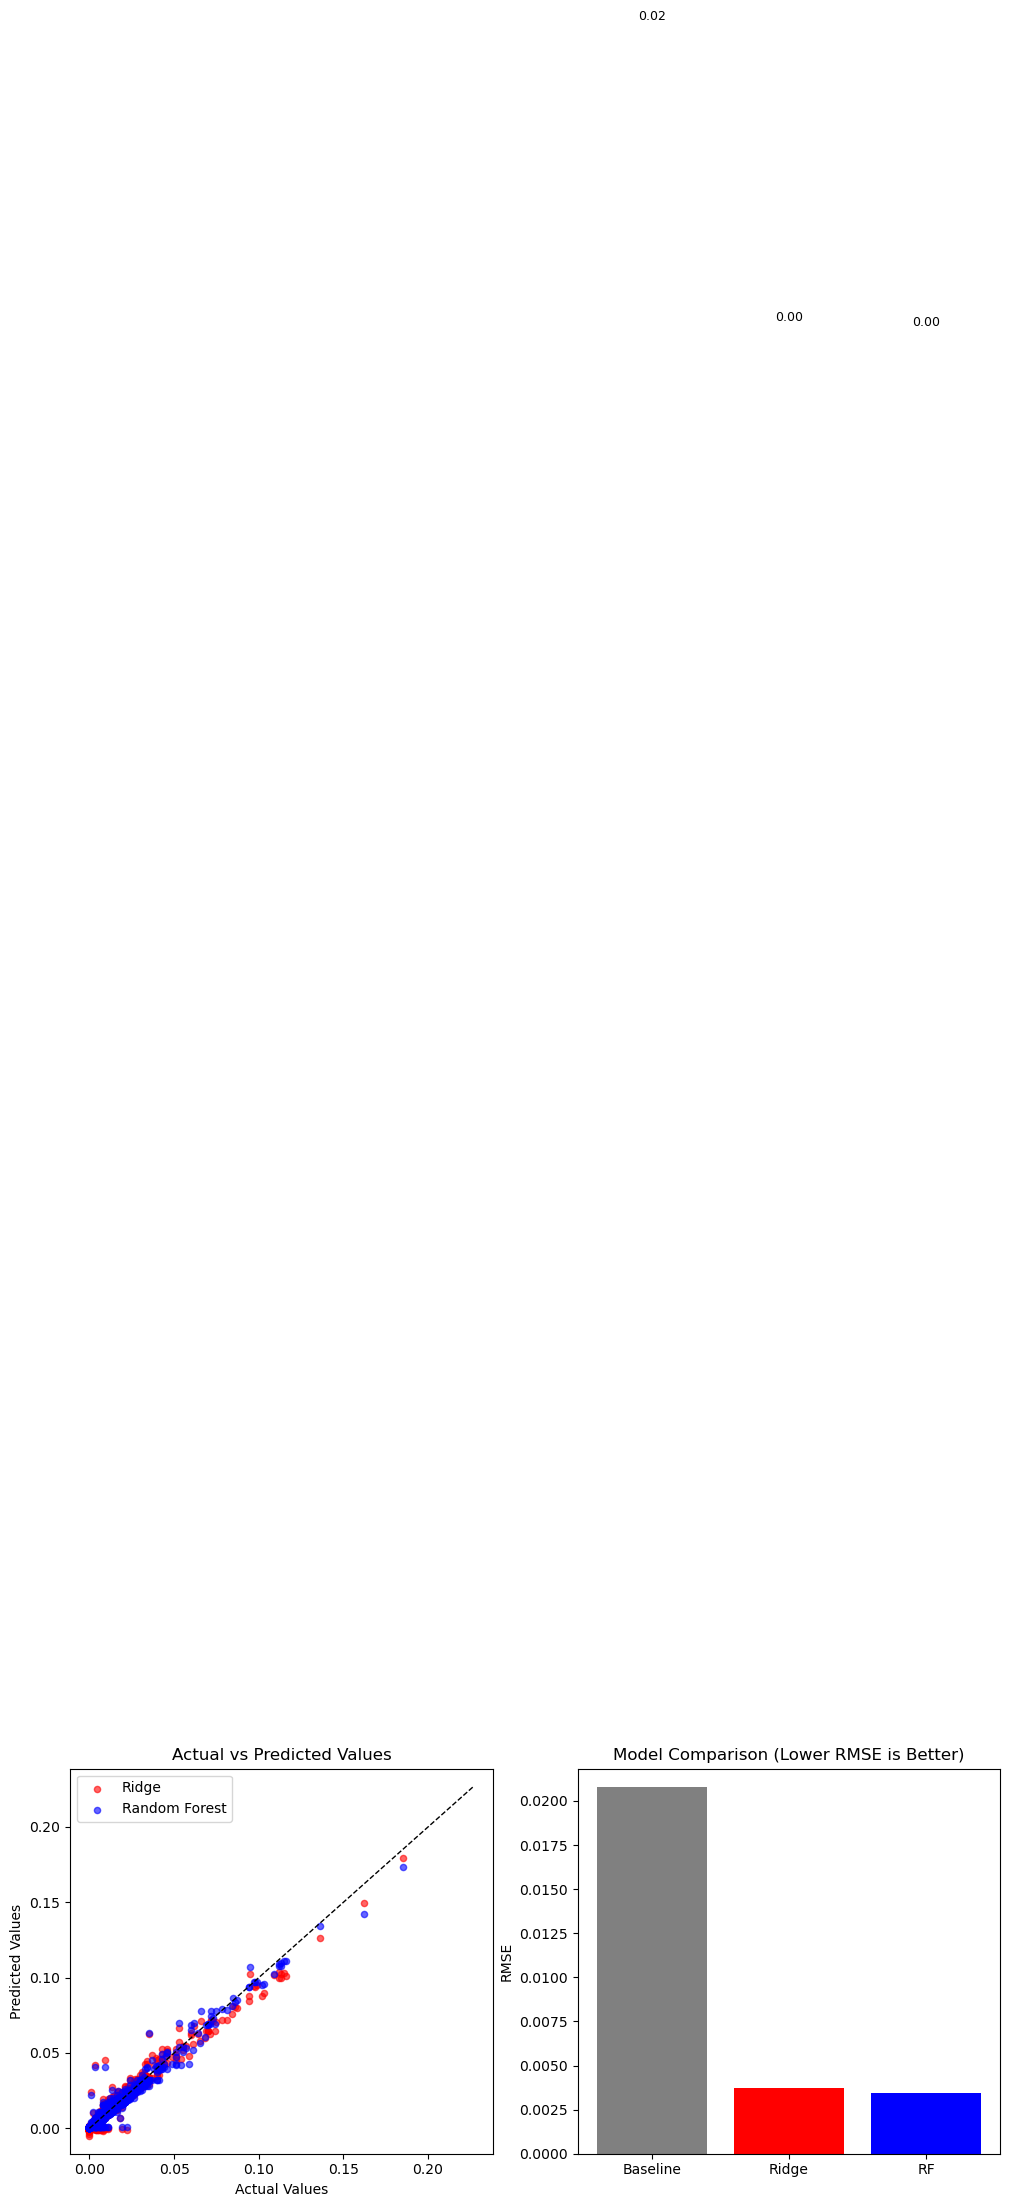


Baseline modeling completed successfully with memory optimization!


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load the dataset in chunks to handle memory issues
file_path = r"C:\Users\Shyam\Downloads\energy consumption dataset\SM Cleaned Data BR2019.csv"

print("Loading dataset in chunks...")

# First, let's inspect the dataset structure without loading everything
try:
    # Get column names and sample
    with pd.read_csv(file_path, nrows=5) as sample_df:
        columns = sample_df.columns.tolist()
        print(f"Columns found: {columns}")
        
        # Identify potential target column
        potential_targets = ['energy', 'consumption', 'power', 'kwh', 'usage', 'demand', 'load']
        target_column = None
        for col in columns:
            if any(keyword in col.lower() for keyword in potential_targets):
                target_column = col
                break
        
        if target_column is None:
            # Use the last numeric column as target
            numeric_cols = sample_df.select_dtypes(include=[np.number]).columns
            target_column = numeric_cols[-1] if len(numeric_cols) > 0 else columns[-1]
        
        print(f"Target column identified: {target_column}")
        
        # Identify date columns to exclude
        date_columns = []
        for col in columns:
            if sample_df[col].dtype == 'object':
                sample_value = str(sample_df[col].iloc[0]) if len(sample_df[col]) > 0 else ''
                if any(keyword in col.lower() or any(char in sample_value for char in ['-', '/', ':']) 
                       for keyword in ['date', 'time', 'timestamp', 'hour', 'day', 'month', 'year']):
                    date_columns.append(col)
        
        print(f"Date columns to exclude: {date_columns}")
        
        # Define columns to keep (exclude date columns)
        columns_to_keep = [col for col in columns if col not in date_columns]
        print(f"Columns to keep: {columns_to_keep}")

except Exception as e:
    print(f"Error inspecting file: {e}")
    exit()

# Now load the dataset in chunks with only necessary columns
chunk_size = 10000  # Adjust based on your memory
chunks = []
total_rows = 0

try:
    for i, chunk in enumerate(pd.read_csv(file_path, usecols=columns_to_keep, chunksize=chunk_size)):
        chunks.append(chunk)
        total_rows += len(chunk)
        print(f"Loaded chunk {i+1}, total rows: {total_rows}")
        
        # For memory efficiency, we'll process each chunk and keep only summary statistics
        # or sample the data if it's too large
        
        if total_rows > 50000:  # Limit to 50,000 rows for baseline modeling
            print("Reached row limit for baseline modeling. Stopping data loading.")
            break

except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# Combine chunks
if chunks:
    df = pd.concat(chunks, ignore_index=True)
    print(f"Final dataset shape: {df.shape}")
else:
    print("No data loaded. Exiting.")
    exit()

# If dataset is still too large, sample it
if len(df) > 50000:
    print("Dataset too large. Sampling 50,000 rows for baseline modeling...")
    df = df.sample(n=50000, random_state=42)
    print(f"Sampled dataset shape: {df.shape}")

# Handle missing values
print("\n=== Handling Missing Values ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if df.isnull().sum().sum() > 0:
    print("Filling missing values...")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')

# Prepare features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Handle categorical variables with memory-efficient approach
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    print(f"Categorical columns: {list(categorical_cols)}")
    
    # For high-cardinality categorical variables, consider grouping or dropping
    for col in categorical_cols:
        unique_count = X[col].nunique()
        print(f"Column '{col}' has {unique_count} unique values")
        
        if unique_count > 50:  # High cardinality
            print(f"High cardinality in '{col}'. Using frequency encoding...")
            # Frequency encoding: replace categories with their frequency
            freq_map = X[col].value_counts().to_dict()
            X[col] = X[col].map(freq_map)
        else:
            # Label encoding for low cardinality
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

# Convert all columns to numeric to ensure compatibility
for col in X.columns:
    if not np.issubdtype(X[col].dtype, np.number):
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Drop any remaining NaN values
X = X.dropna(axis=1, how='all')  # Drop columns with all NaN
X = X.fillna(0)  # Fill any remaining NaN with 0

print(f"Final features shape: {X.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Model 1: Ridge Regression
print("\n" + "="*50)
print("BASELINE MODEL 1: RIDGE REGRESSION")
print("="*50)

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Mean Absolute Error (MAE): {mae_ridge:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.4f}")
print(f"R-squared (R²): {r2_ridge:.4f}")

# Baseline Model 2: Simple Random Forest
print("\n" + "="*50)
print("BASELINE MODEL 2: RANDOM FOREST (Simplified)")
print("="*50)

# Use a simpler random forest to save memory
rf_model = RandomForestRegressor(
    n_estimators=30,      # Reduced number of trees
    max_depth=5,          # Shallow trees
    max_samples=0.5,      # Use only 50% of data for each tree
    random_state=42,
    n_jobs=1              # Single job to save memory
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"R-squared (R²): {r2_rf:.4f}")

# Baseline prediction (mean of training data)
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

# Final comparison
print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(f"{'Metric':<20} {'Baseline (Mean)':<15} {'Ridge Regression':<18} {'Random Forest':<15}")
print(f"{'MAE':<20} {baseline_mae:<15.4f} {mae_ridge:<18.4f} {mae_rf:<15.4f}")
print(f"{'RMSE':<20} {baseline_rmse:<15.4f} {rmse_ridge:<18.4f} {rmse_rf:<15.4f}")
print(f"{'R²':<20} {baseline_r2:<15.4f} {r2_ridge:<18.4f} {r2_rf:<15.4f}")

# Simple visualization
plt.figure(figsize=(12, 5))

# Actual vs Predicted
plt.subplot(1, 2, 1)
sample_size = min(1000, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)
plt.scatter(y_test.iloc[sample_indices], y_pred_ridge[sample_indices], 
            alpha=0.6, label='Ridge', s=20, color='red')
plt.scatter(y_test.iloc[sample_indices], y_pred_rf[sample_indices], 
            alpha=0.6, label='Random Forest', s=20, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()

# Model comparison
plt.subplot(1, 2, 2)
models = ['Baseline', 'Ridge', 'RF']
rmse_values = [baseline_rmse, rmse_ridge, rmse_rf]
colors = ['gray', 'red', 'blue']
bars = plt.bar(models, rmse_values, color=colors)
plt.ylabel('RMSE')
plt.title('Model Comparison (Lower RMSE is Better)')

for bar, value in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{value:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nBaseline modeling completed successfully with memory optimization!")

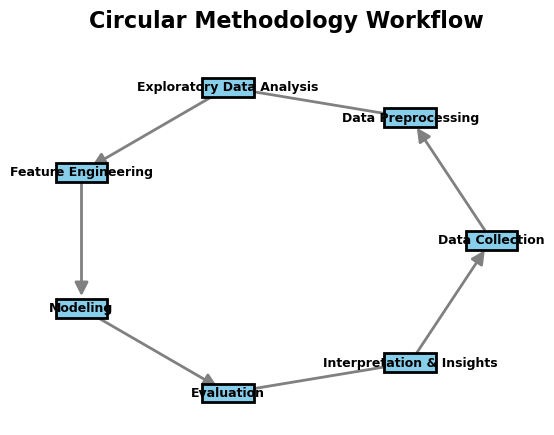

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Define methodology steps
steps = [
    "Data Collection",
    "Data Preprocessing",
    "Exploratory Data Analysis",
    "Feature Engineering",
    "Modeling",
    "Evaluation",
    "Interpretation & Insights"
]

# Add edges to define flow
for i in range(len(steps)-1):
    G.add_edge(steps[i], steps[i+1])
G.add_edge(steps[-1], steps[0])  # Optional: close the circle if needed

# Circular layout
pos = nx.circular_layout(G)

# Draw edges with arrows
nx.draw_networkx_edges(
    G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2
)

# Draw rectangular nodes
for node, (x, y) in pos.items():
    plt.gca().add_patch(plt.Rectangle(
        (x-0.12, y-0.06), 0.24, 0.12,  # box size
        facecolor='#87CEEB', edgecolor='black', lw=2
    ))
    plt.text(x, y, node, fontsize=9, fontweight='bold',
             horizontalalignment='center', verticalalignment='center', wrap=True)

# Remove axes and title
plt.axis('off')
plt.title("Circular Methodology Workflow", fontsize=16, fontweight='bold', pad=20)
plt.show()
